In [6]:
import os
import pandas as pd

# Files are directly inside the "data" folder (one level up from notebooks)
national     = pd.read_csv("../data/nigeria_flu_weekly_national.csv")
state_weekly = pd.read_csv("../data/nigeria_flu_weekly_by_state.csv")
incidence    = pd.read_csv("../data/nigeria_flu_season_reference.csv")
seasonal     = pd.read_csv("../data/nigeria_flu_season_summary.csv")
metadata     = pd.read_csv("../data/nigeria_flu_state_metadata.csv")

# Verify
print("National:", national.shape)
print("State weekly:", state_weekly.shape)
print("Season reference:", incidence.shape)
print("Season summary:", seasonal.shape)
print("Metadata:", metadata.shape)

National: (156, 11)
State weekly: (5772, 15)
Season reference: (3, 4)
Season summary: (111, 15)
Metadata: (37, 5)


In [8]:
import pandas as pd
import numpy as np

# Bundle all your dataframes into a dict so we can loop over them
datasets = {
    "national":      national,
    "state_weekly":  state_weekly,
    "incidence":     incidence,
    "seasonal":      seasonal,
    "metadata":      metadata,
}

def data_quality_report(df, name, id_cols=None):
    print("=" * 70)
    print(f"  {name.upper()}   |   shape = {df.shape}")
    print("=" * 70)

    # ---------- 1. NA CHECK ----------
    na = df.isna().sum()
    na = na[na > 0].sort_values(ascending=False)
    if na.empty:
        print("✅ No missing values.")
    else:
        print("⚠️  Missing values:")
        na_df = pd.DataFrame({
            "missing": na,
            "pct": (na / len(df) * 100).round(2)
        })
        print(na_df.to_string())

    # ---------- 2. DUPLICATE CHECK ----------
    full_dups = df.duplicated().sum()
    print(f"\nFull-row duplicates: {full_dups}")

    if id_cols:
        # Normalize to only keep cols that actually exist
        key_cols = [c for c in id_cols if c in df.columns]
        if key_cols:
            key_dups = df.duplicated(subset=key_cols).sum()
            print(f"Duplicates on key {key_cols}: {key_dups}")
        else:
            print(f"None of the key cols {id_cols} found in {name}.")

    # ---------- 3. DTYPES ----------
    print("\nDtypes:")
    print(df.dtypes.to_string())

    # ---------- 4. SUMMARY STATS ----------
    num = df.select_dtypes(include=np.number)
    if not num.empty:
        print("\nNumeric summary:")
        print(num.describe().T.round(2).to_string())

    cat = df.select_dtypes(include=["object", "category"])
    if not cat.empty:
        print("\nCategorical summary (n unique / top value):")
        cat_summary = pd.DataFrame({
            "n_unique": cat.nunique(),
            "top_value": cat.mode().iloc[0] if not cat.mode().empty else None,
            "top_freq": [cat[c].value_counts().iloc[0] if not cat[c].value_counts().empty else 0 for c in cat.columns],
        })
        print(cat_summary.to_string())

    print("\n")


# ---- Run the report on every dataset ----
# Define which columns should be unique for each table:
data_quality_report(national,     "national",     id_cols=["season", "epi_week_of_season", "state"])
data_quality_report(state_weekly, "state_weekly", id_cols=["season", "state", "epi_week_of_season"])
data_quality_report(incidence,    "incidence",    id_cols=["season"])
data_quality_report(seasonal,     "seasonal",     id_cols=["season", "state"])
data_quality_report(metadata,     "metadata",     id_cols=["state"])

  NATIONAL   |   shape = (156, 11)
✅ No missing values.

Full-row duplicates: 0
Duplicates on key ['season', 'epi_week_of_season', 'state']: 0

Dtypes:
season                        object
epi_week_of_season             int64
week_start                    object
cases                          int64
hospitalizations               int64
deaths                         int64
population                     int64
cases_per_100k               float64
hospitalizations_per_100k    float64
deaths_per_100k              float64
state                         object

Numeric summary:
                           count          mean        std           min           25%           50%           75%           max
epi_week_of_season         156.0  2.650000e+01      15.06  1.000000e+00  1.375000e+01  2.650000e+01  3.925000e+01  5.200000e+01
cases                      156.0  4.536588e+05  914627.23  7.648000e+03  2.627250e+04  3.608400e+04  3.645722e+05  4.408272e+06
hospitalizations           156.0  6.735

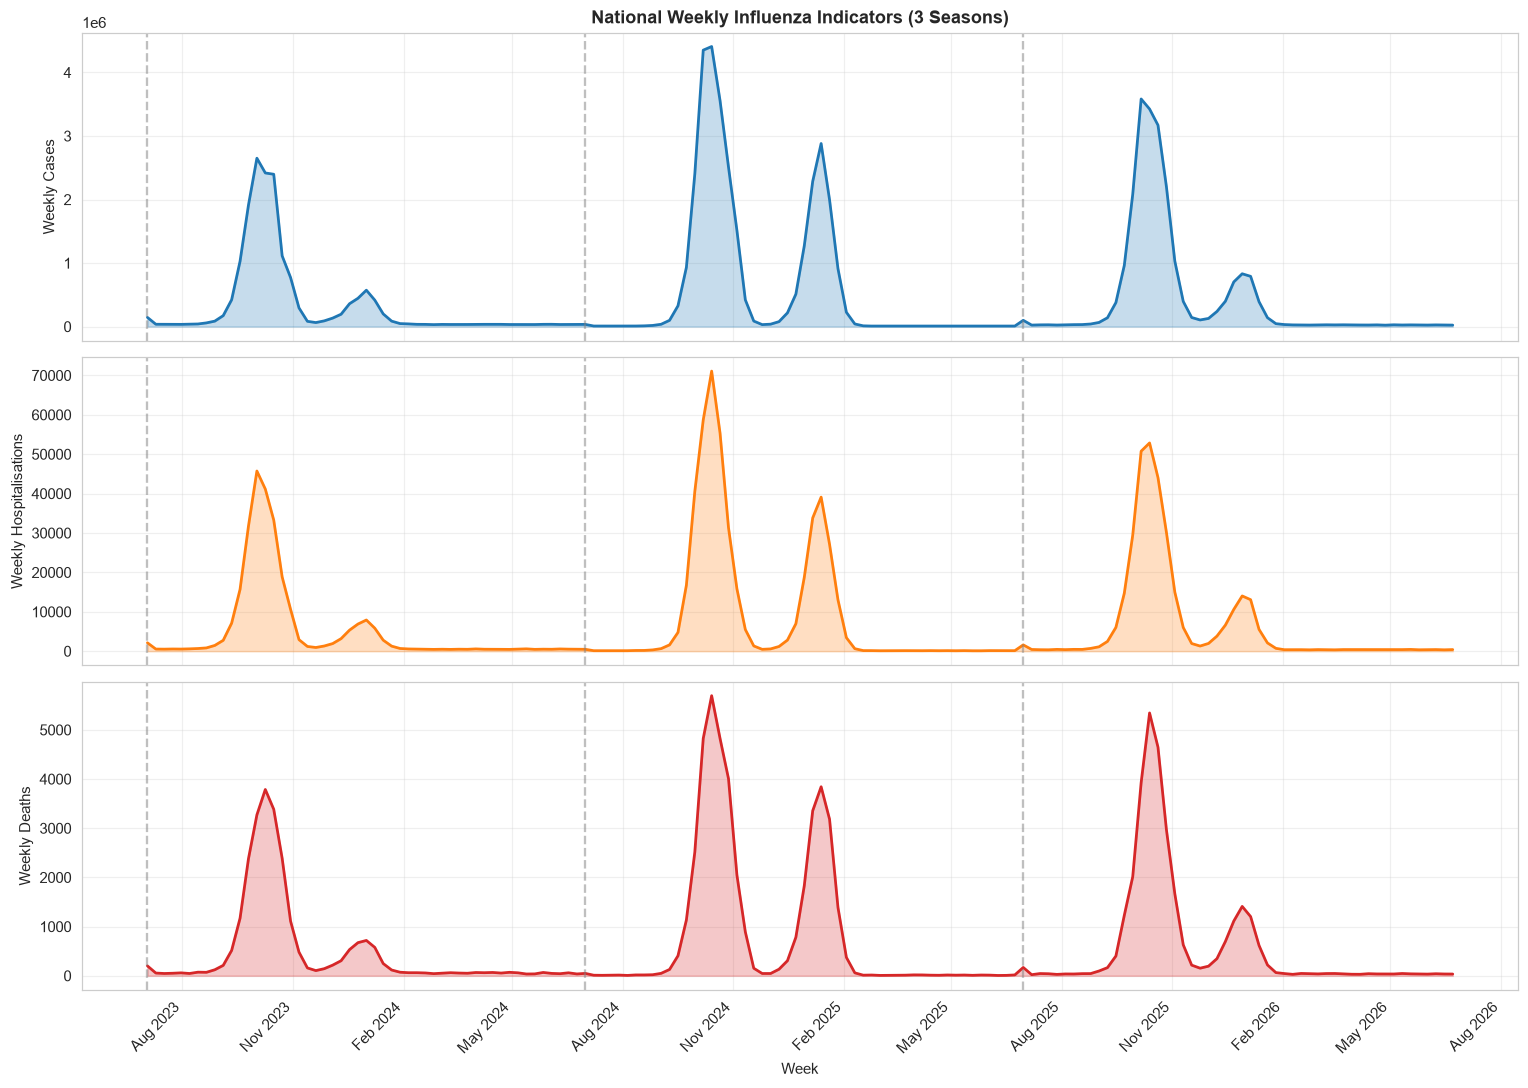

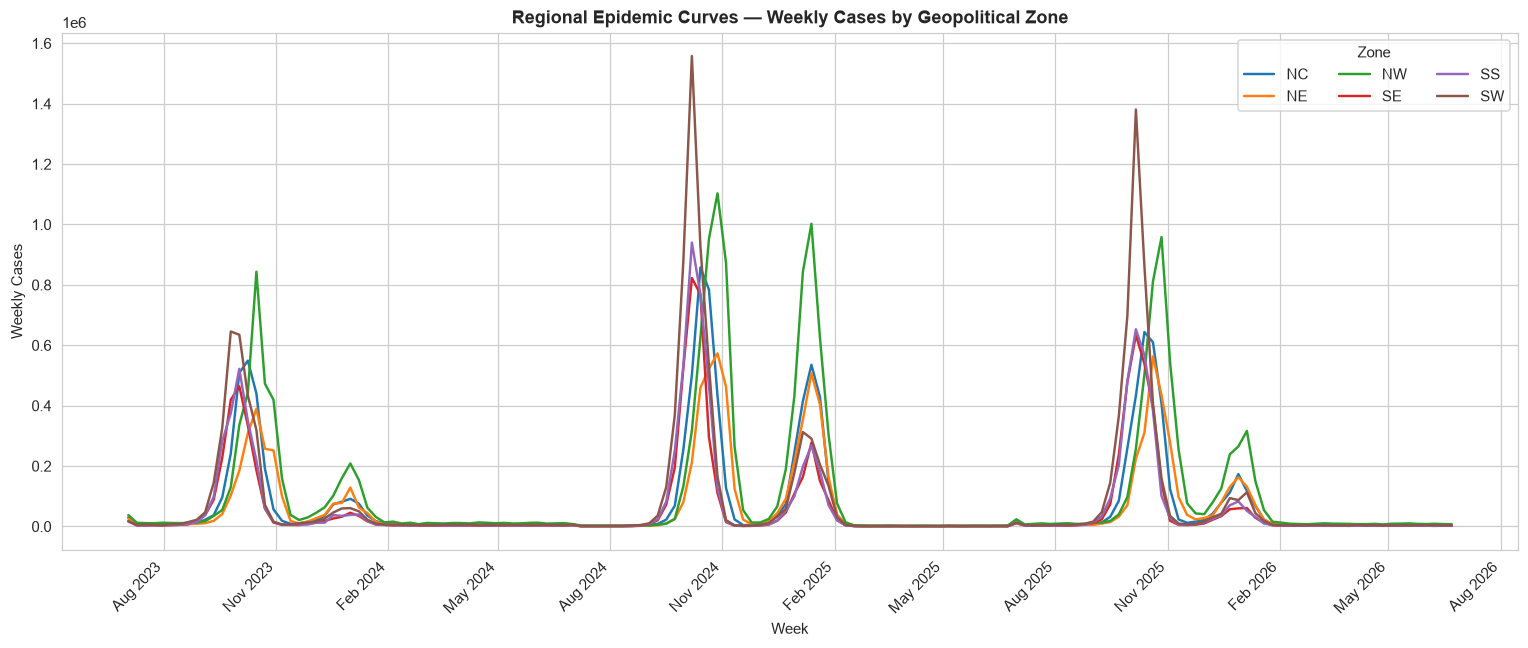

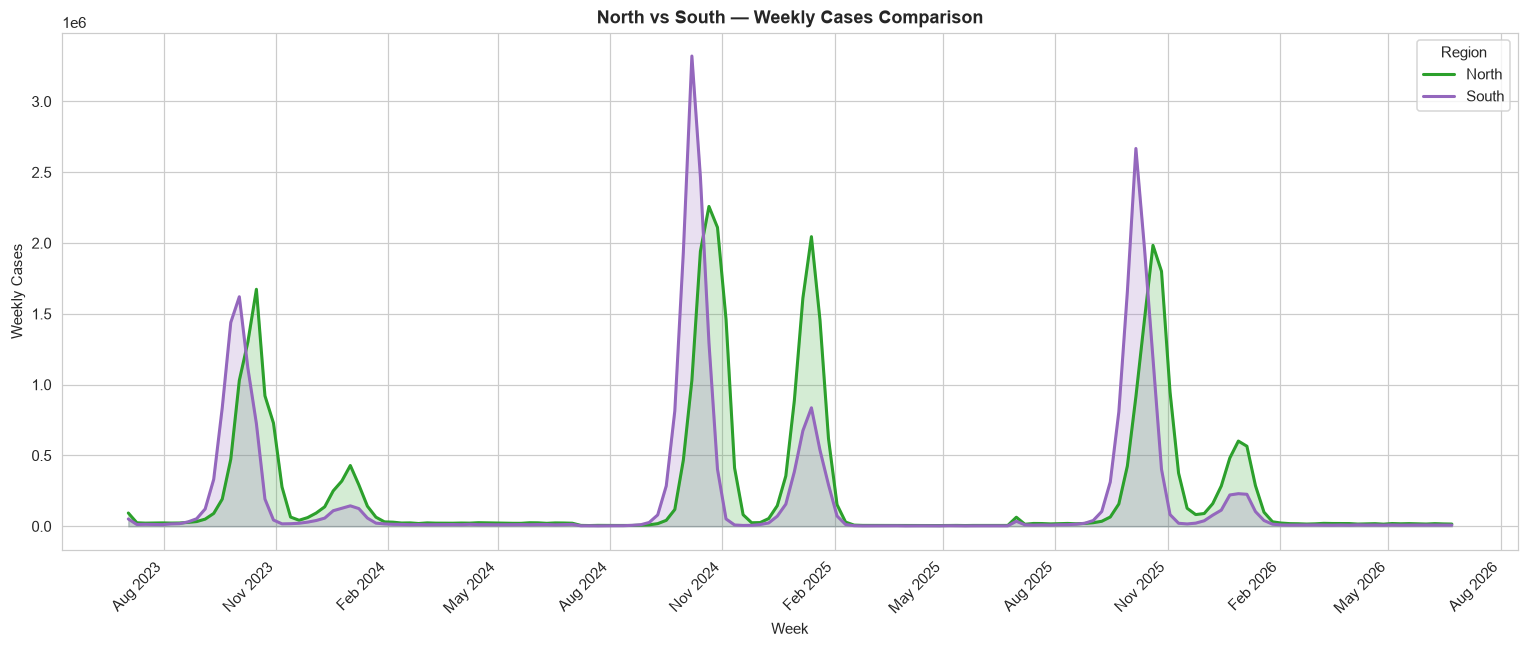

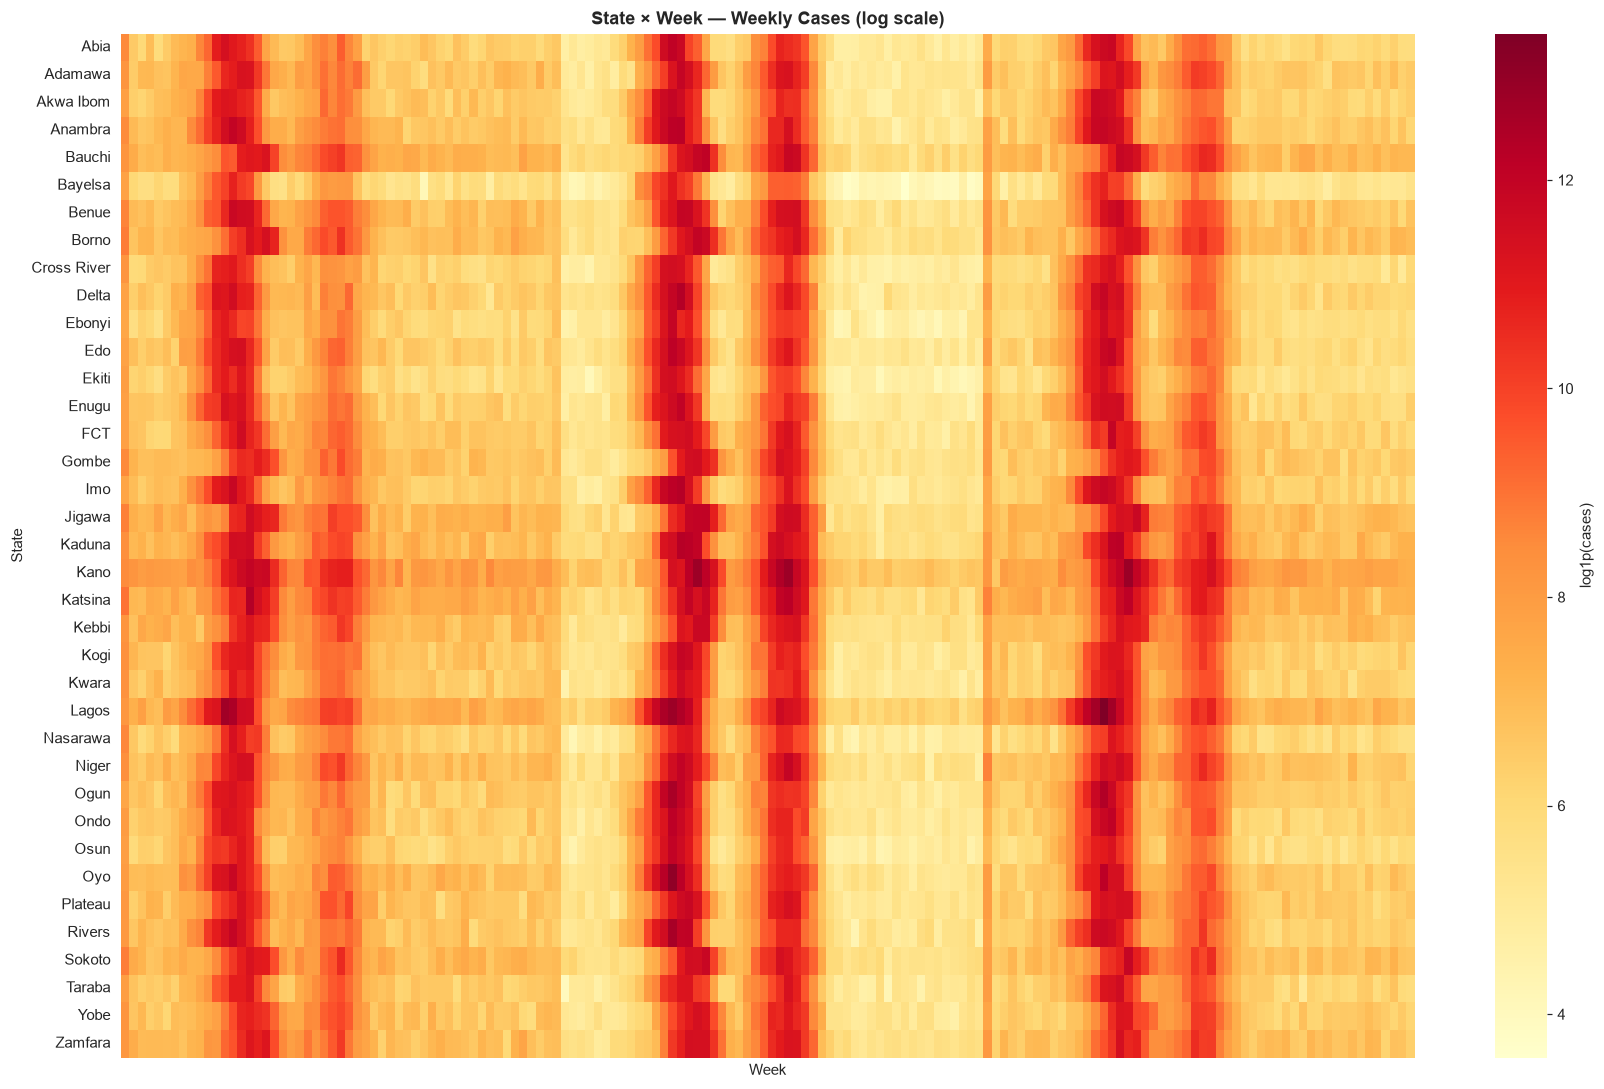

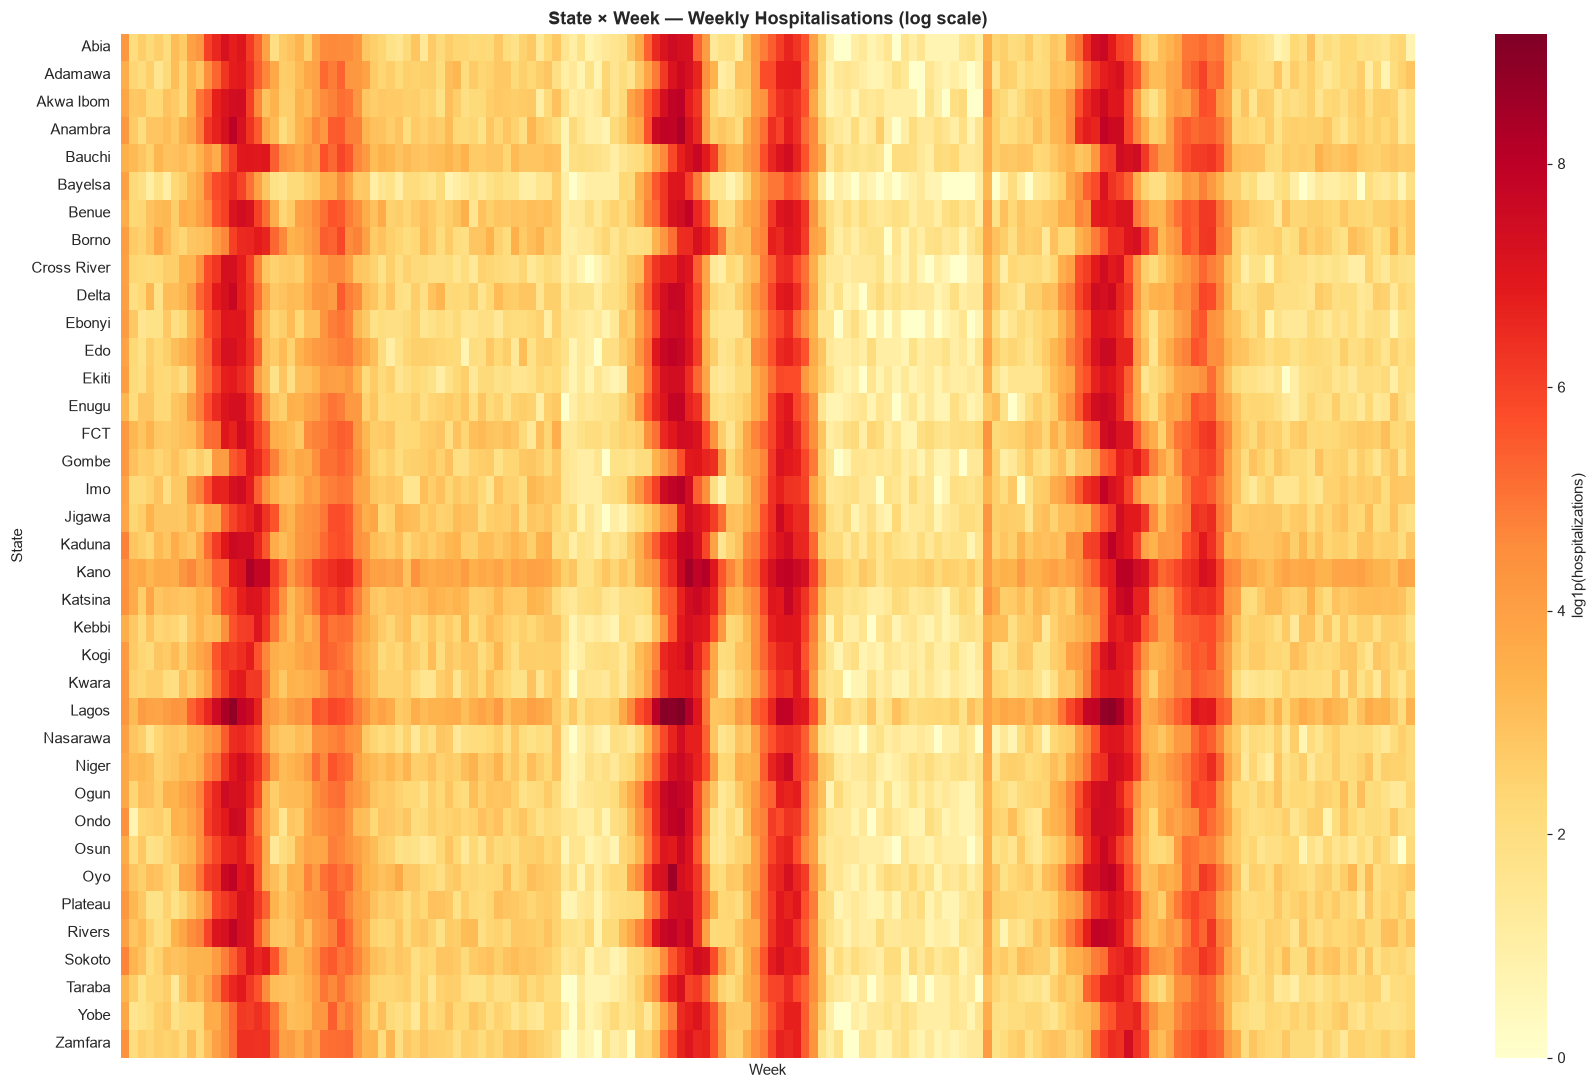

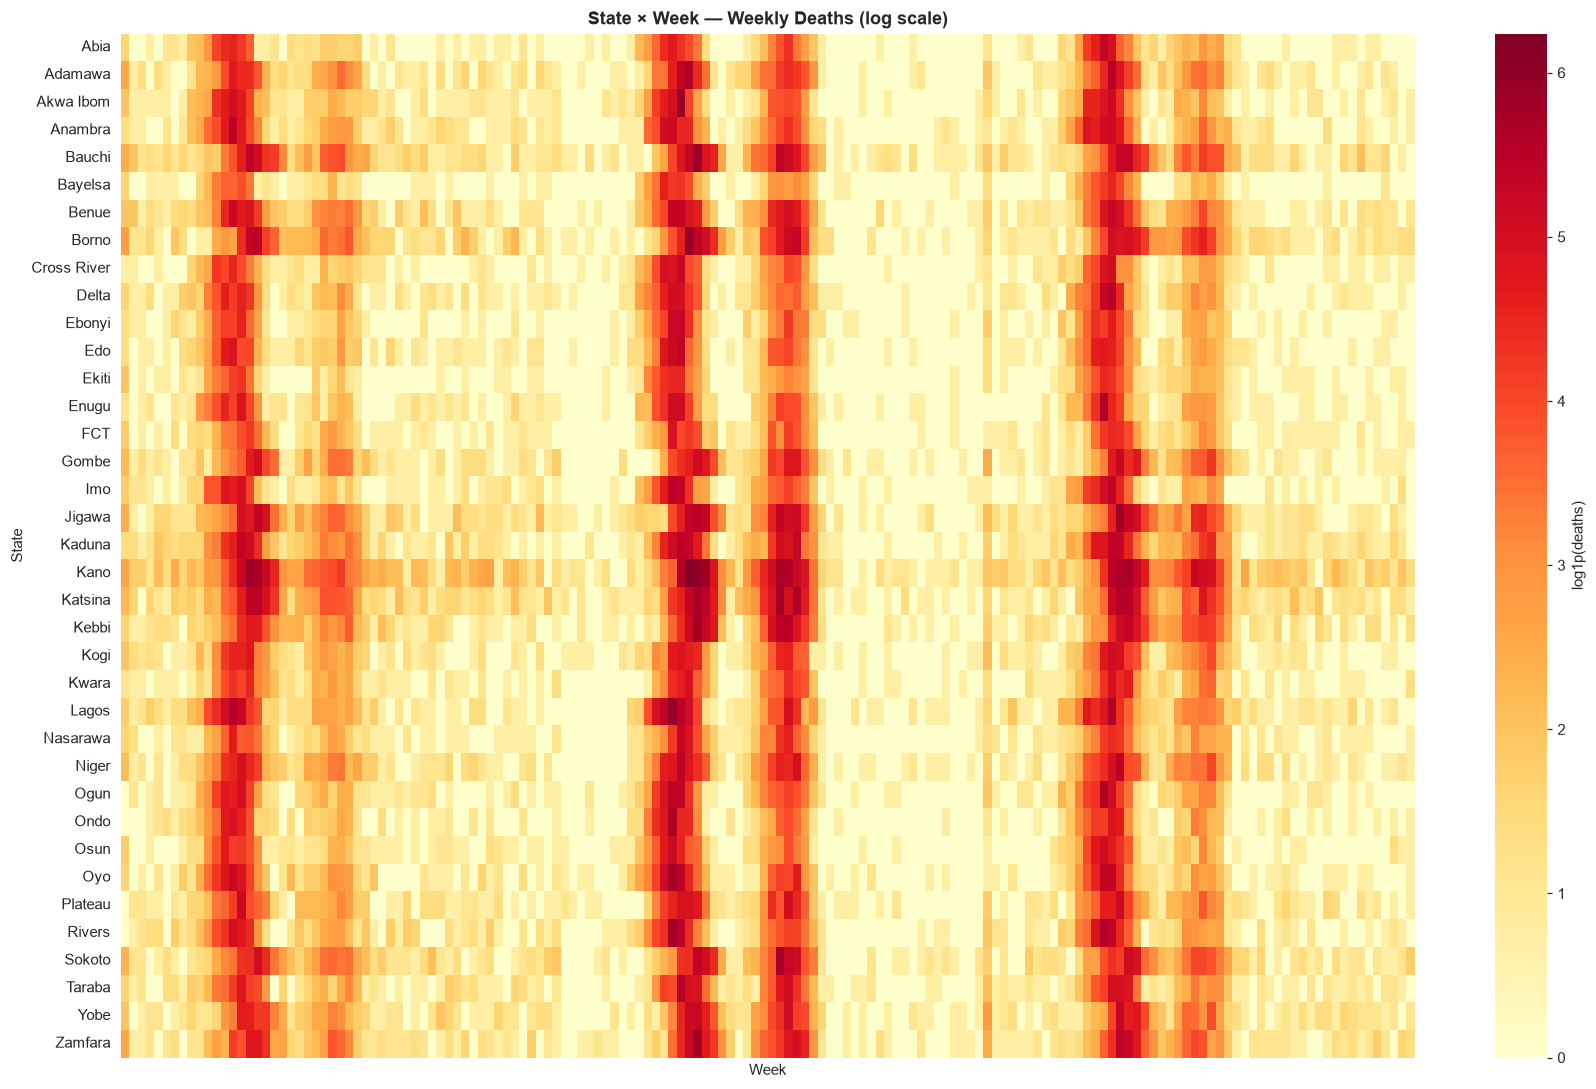

C:\Users\User\AppData\Local\Temp\ipykernel_6596\1353355991.py:184: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_6596\1353355991.py:185: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(f'{FIG_DIR}/attack_rate_map.png', bbox_inches='tight')
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


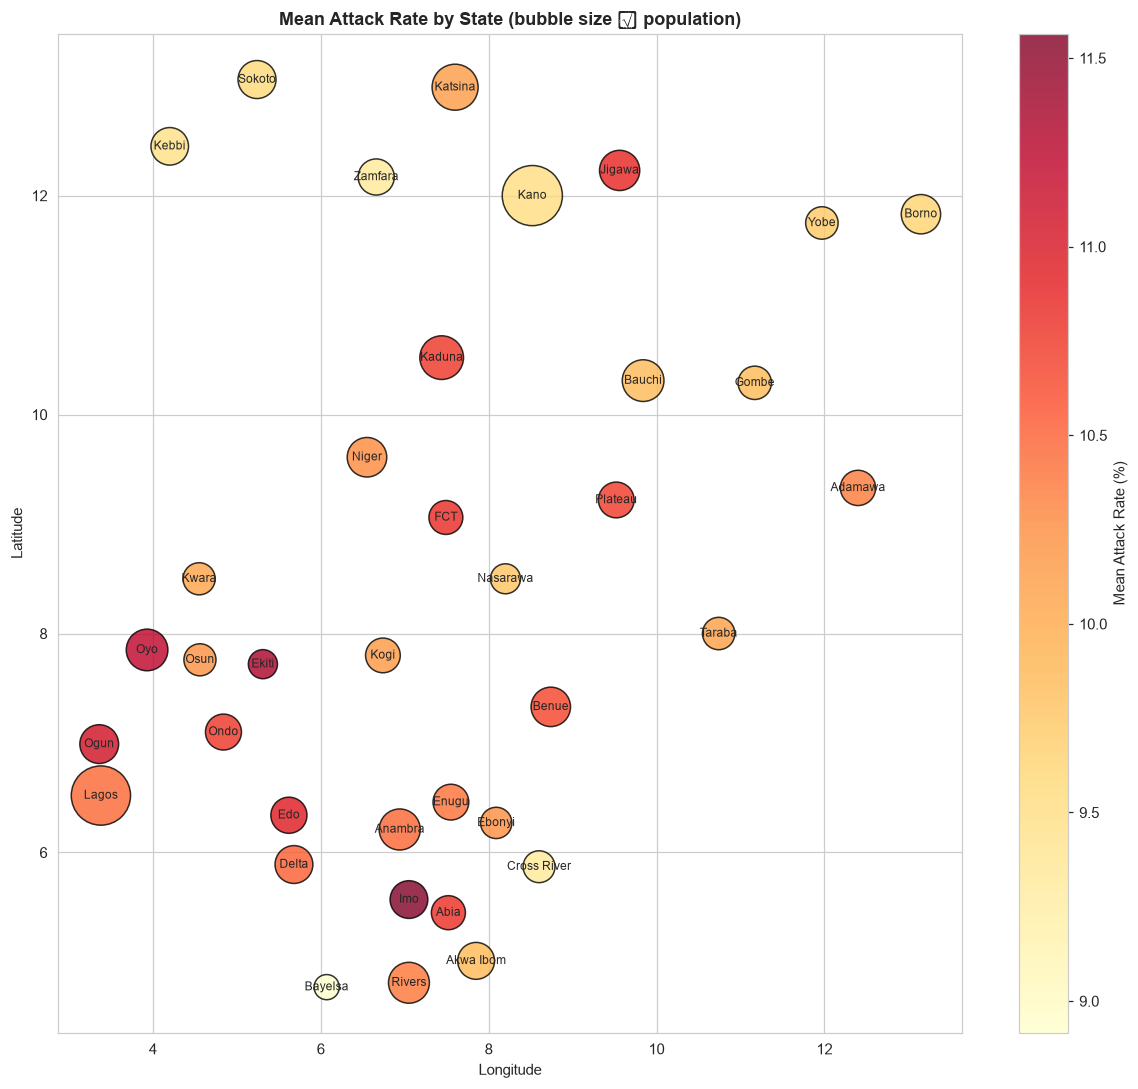

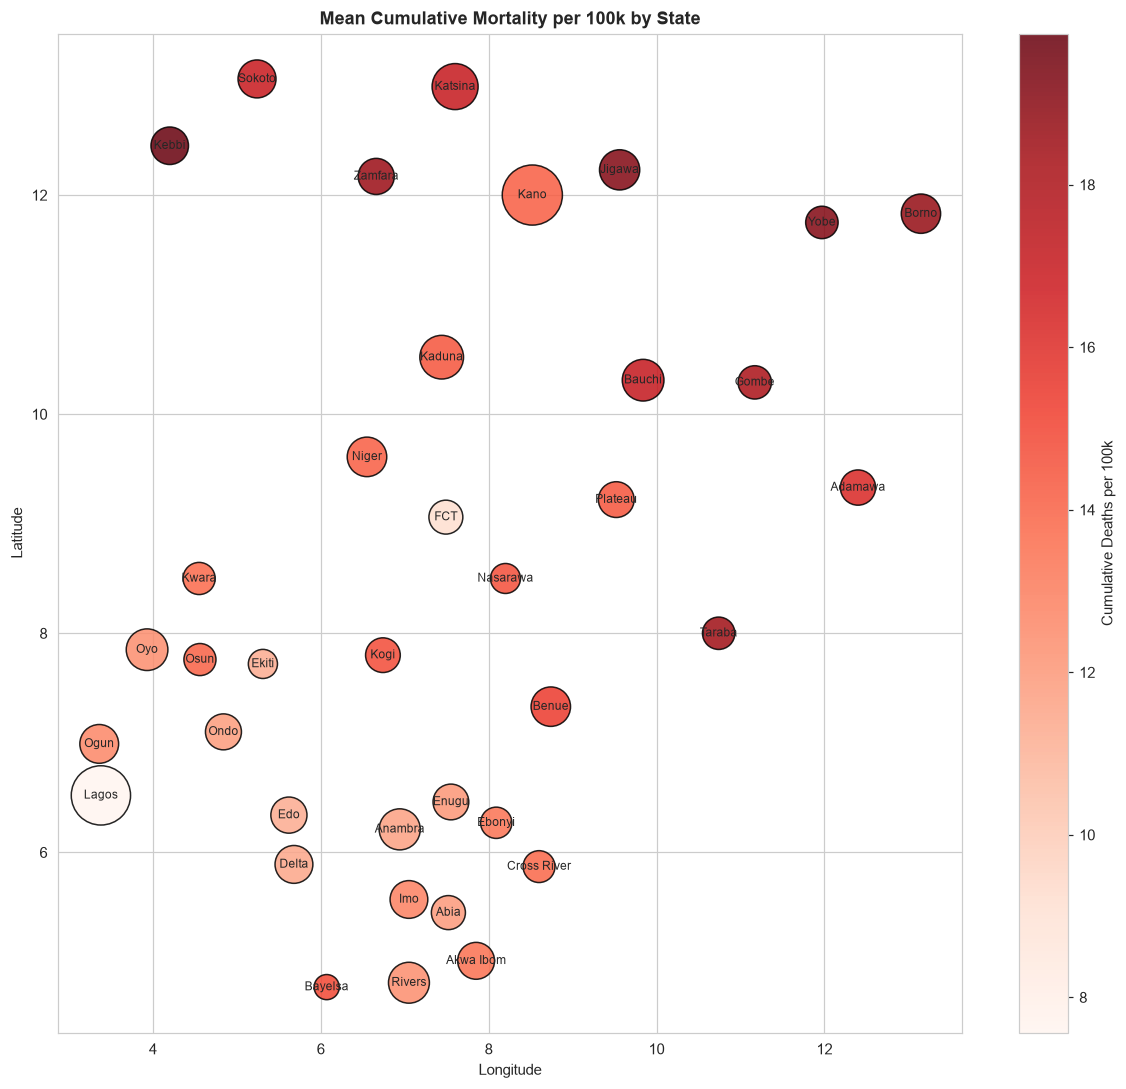

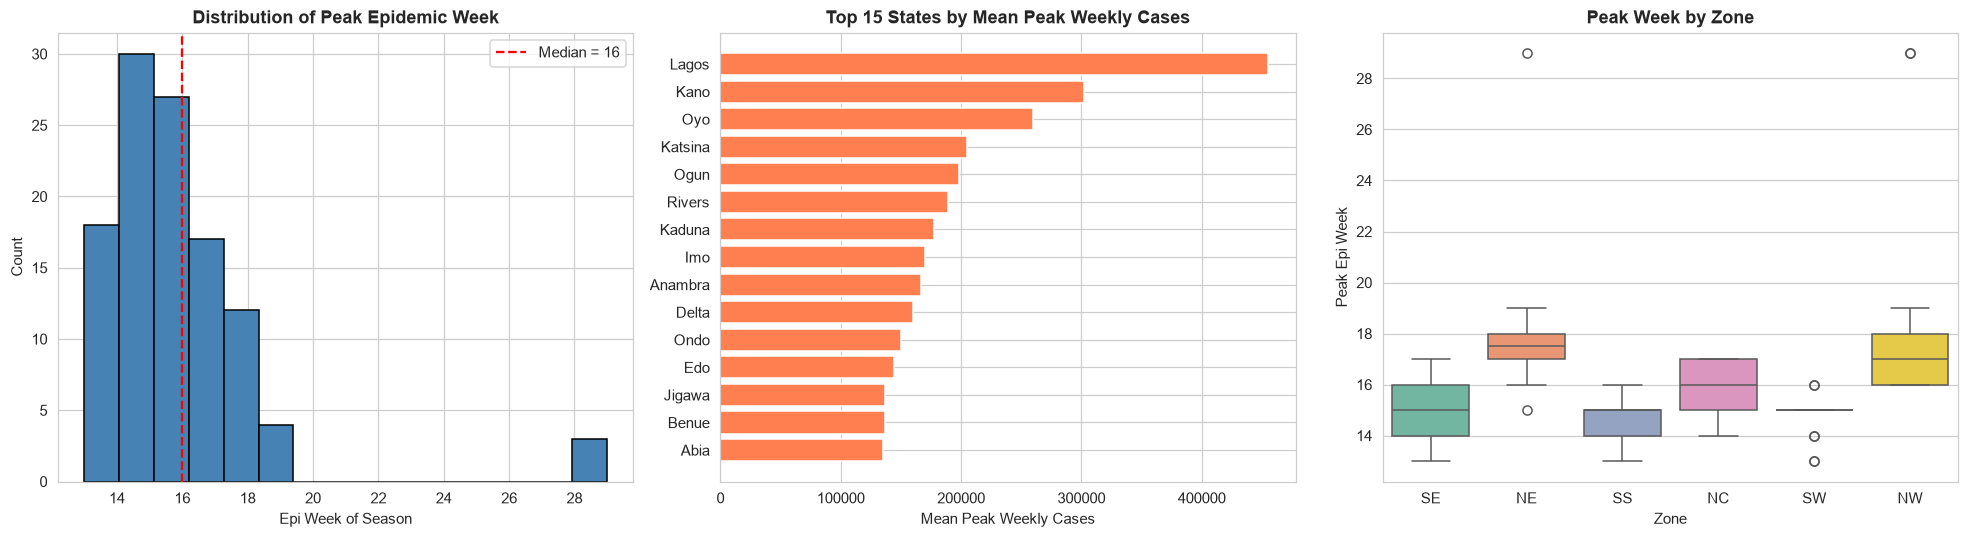

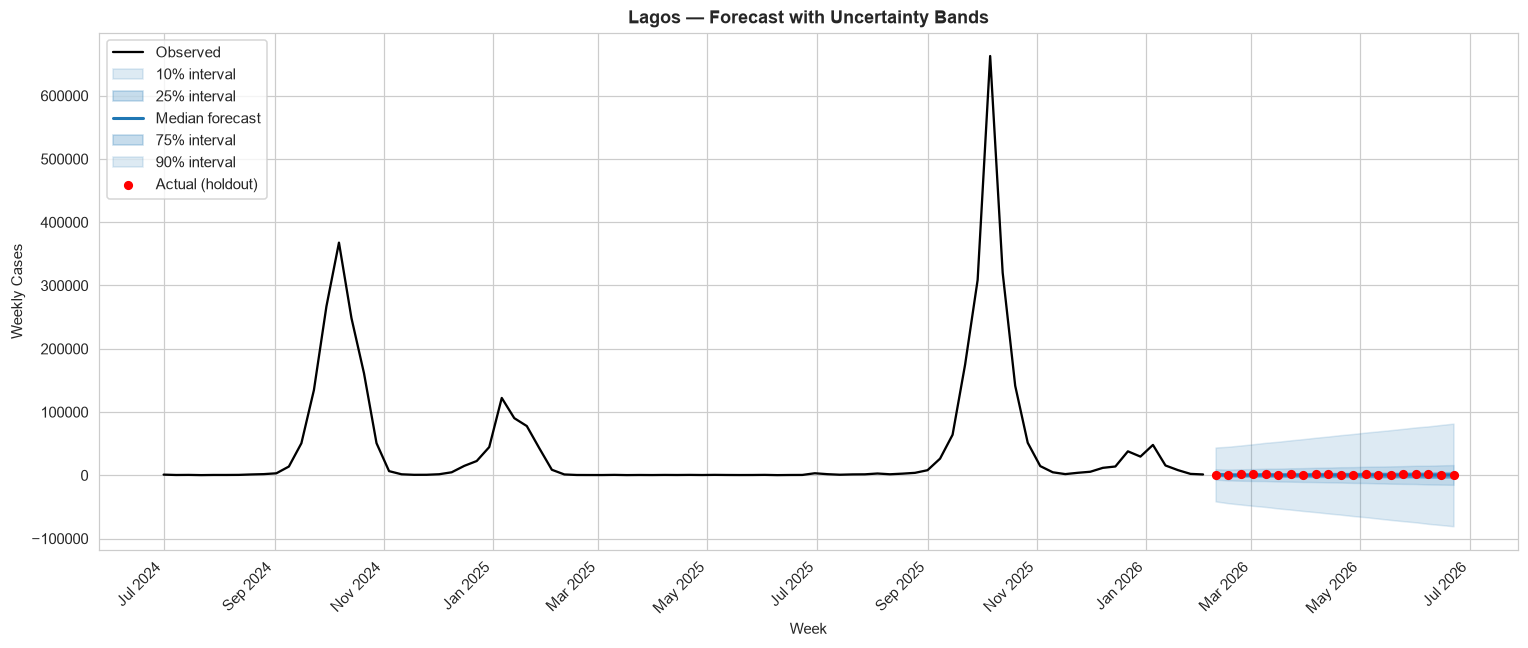

In [ ]:

# ------------------------------------------------------------
# 0. IMPORTS AND GLOBAL SETUP
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi']       = 110
plt.rcParams['savefig.dpi']      = 150
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)


# ------------------------------------------------------------
# 1. DATA PREPARATION — DATE PARSING AND REGION LABELS
# ------------------------------------------------------------
national['week_start']       = pd.to_datetime(national['week_start'])
state_weekly['week_start']   = pd.to_datetime(state_weekly['week_start'])
seasonal['peak_week_start']  = pd.to_datetime(seasonal['peak_week_start'])
incidence['season_start']    = pd.to_datetime(incidence['season_start'])

# Nigeria's six geopolitical zones split into North / South
NORTH_ZONES = ['NC', 'NE', 'NW']
SOUTH_ZONES = ['SS', 'SE', 'SW']

state_weekly['region'] = np.where(
    state_weekly['zone'].isin(NORTH_ZONES), 'North', 'South'
)


# ------------------------------------------------------------
# 2. NATIONAL WEEKLY CASES, HOSPITALISATIONS, DEATHS
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

metrics = [
    ('cases',            'Weekly Cases',            '#1f77b4'),
    ('hospitalizations', 'Weekly Hospitalisations', '#ff7f0e'),
    ('deaths',           'Weekly Deaths',           '#d62728'),
]

for ax, (col, title, color) in zip(axes, metrics):
    ax.plot(national['week_start'], national[col], color=color, lw=1.8)
    ax.fill_between(national['week_start'], national[col], alpha=0.25, color=color)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(alpha=0.3)
    for _, row in incidence.iterrows():
        ax.axvline(row['season_start'], color='grey', ls='--', alpha=0.5)

axes[0].set_title('National Weekly Influenza Indicators (3 Seasons)')
axes[-1].set_xlabel('Week')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/national_weekly_indicators.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 3. REGIONAL EPIDEMIC CURVES BY GEOPOLITICAL ZONE
# ------------------------------------------------------------
zone_weekly = (state_weekly
               .groupby(['zone', 'week_start'], as_index=False)
               .agg(cases=('cases','sum'),
                    hospitalizations=('hospitalizations','sum'),
                    deaths=('deaths','sum')))

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("tab10", n_colors=zone_weekly['zone'].nunique())

for (zone, grp), color in zip(zone_weekly.groupby('zone'), palette):
    ax.plot(grp['week_start'], grp['cases'], label=zone, lw=1.6, color=color)

ax.set_title('Regional Epidemic Curves — Weekly Cases by Geopolitical Zone')
ax.set_xlabel('Week')
ax.set_ylabel('Weekly Cases')
ax.legend(title='Zone', ncol=3, frameon=True)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/regional_epidemic_curves.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 4. NORTH VS SOUTH WAVE COMPARISON
# ------------------------------------------------------------
region_weekly = (state_weekly
                 .groupby(['region', 'week_start'], as_index=False)['cases']
                 .sum())

fig, ax = plt.subplots(figsize=(14, 6))
for region, color in zip(['North', 'South'], ['#2ca02c', '#9467bd']):
    sub = region_weekly[region_weekly['region'] == region]
    ax.plot(sub['week_start'], sub['cases'], label=region, lw=2, color=color)
    ax.fill_between(sub['week_start'], sub['cases'], alpha=0.2, color=color)

ax.set_title('North vs South — Weekly Cases Comparison')
ax.set_xlabel('Week')
ax.set_ylabel('Weekly Cases')
ax.legend(title='Region')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/north_vs_south.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 5. STATE-LEVEL WEEKLY HEATMAPS (CASES, HOSP., DEATHS)
# ------------------------------------------------------------
def plot_state_heatmap(df, value_col, title, cmap='YlOrRd'):
    pivot = df.pivot_table(
        index='state', columns='week_start', values=value_col, aggfunc='sum'
    ).sort_index()
    pivot = np.log1p(pivot)

    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(pivot, cmap=cmap, ax=ax,
                cbar_kws={'label': f'log1p({value_col})'},
                xticklabels=False)
    ax.set_title(title)
    ax.set_xlabel('Week')
    ax.set_ylabel('State')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/heatmap_{value_col}.png', bbox_inches='tight')
    plt.show()

plot_state_heatmap(state_weekly, 'cases',
                   'State × Week — Weekly Cases (log scale)')
plot_state_heatmap(state_weekly, 'hospitalizations',
                   'State × Week — Weekly Hospitalisations (log scale)')
plot_state_heatmap(state_weekly, 'deaths',
                   'State × Week — Weekly Deaths (log scale)')


# ------------------------------------------------------------
# 6. STATE ATTACK-RATE MAP
# ------------------------------------------------------------
state_coords = {
    'Abia':(5.45,7.52),'Adamawa':(9.33,12.40),'Akwa Ibom':(5.01,7.85),
    'Anambra':(6.21,6.94),'Bauchi':(10.31,9.84),'Bayelsa':(4.77,6.07),
    'Benue':(7.33,8.74),'Borno':(11.83,13.15),'Cross River':(5.87,8.60),
    'Delta':(5.89,5.68),'Ebonyi':(6.27,8.09),'Edo':(6.34,5.62),
    'Ekiti':(7.72,5.31),'Enugu':(6.46,7.55),'FCT':(9.06,7.49),
    'Gombe':(10.29,11.17),'Imo':(5.57,7.05),'Jigawa':(12.23,9.56),
    'Kaduna':(10.52,7.44),'Kano':(12.00,8.52),'Katsina':(12.99,7.60),
    'Kebbi':(12.45,4.20),'Kogi':(7.80,6.74),'Kwara':(8.50,4.55),
    'Lagos':(6.52,3.38),'Nasarawa':(8.50,8.20),'Niger':(9.61,6.55),
    'Ogun':(6.99,3.36),'Ondo':(7.10,4.84),'Osun':(7.76,4.56),
    'Oyo':(7.85,3.93),'Plateau':(9.22,9.52),'Rivers':(4.81,7.05),
    'Sokoto':(13.06,5.24),'Taraba':(8.00,10.74),'Yobe':(11.75,11.97),
    'Zamfara':(12.17,6.66),
}

ar = (seasonal.groupby('state')
      .agg(attack_rate=('attack_rate_pct','mean'),
           population=('population','first'))
      .reset_index())
ar['lat'] = ar['state'].map(lambda s: state_coords.get(s, (np.nan, np.nan))[0])
ar['lon'] = ar['state'].map(lambda s: state_coords.get(s, (np.nan, np.nan))[1])
ar = ar.dropna(subset=['lat','lon'])

fig, ax = plt.subplots(figsize=(11, 10))
sizes = (ar['population'] / ar['population'].max()) * 1500 + 50
sc = ax.scatter(ar['lon'], ar['lat'], s=sizes, c=ar['attack_rate'],
                cmap='YlOrRd', edgecolor='black', alpha=0.8)
for _, r in ar.iterrows():
    ax.annotate(r['state'], (r['lon'], r['lat']),
                fontsize=8, ha='center', va='center')
plt.colorbar(sc, ax=ax, label='Mean Attack Rate (%)')
ax.set_title('Mean Attack Rate by State (bubble size ∝ population)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/attack_rate_map.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 7. STATE MORTALITY MAP
# ------------------------------------------------------------
mort = (seasonal.groupby('state')
        .agg(cum_deaths_per_100k=('cum_deaths_per_100k','mean'),
             population=('population','first'))
        .reset_index())
mort['lat'] = mort['state'].map(lambda s: state_coords.get(s, (np.nan, np.nan))[0])
mort['lon'] = mort['state'].map(lambda s: state_coords.get(s, (np.nan, np.nan))[1])
mort = mort.dropna(subset=['lat','lon'])

fig, ax = plt.subplots(figsize=(11, 10))
sizes = (mort['population'] / mort['population'].max()) * 1500 + 50
sc = ax.scatter(mort['lon'], mort['lat'], s=sizes,
                c=mort['cum_deaths_per_100k'],
                cmap='Reds', edgecolor='black', alpha=0.85)
for _, r in mort.iterrows():
    ax.annotate(r['state'], (r['lon'], r['lat']),
                fontsize=8, ha='center', va='center')
plt.colorbar(sc, ax=ax, label='Cumulative Deaths per 100k')
ax.set_title('Mean Cumulative Mortality per 100k by State')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/mortality_map.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 8. PEAK-WEEK SUMMARIES
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Distribution of peak epi week
axes[0].hist(seasonal['peak_epi_week'], bins=15,
             color='steelblue', edgecolor='black')
axes[0].axvline(seasonal['peak_epi_week'].median(), color='red', ls='--',
                label=f"Median = {seasonal['peak_epi_week'].median():.0f}")
axes[0].set_title('Distribution of Peak Epidemic Week')
axes[0].set_xlabel('Epi Week of Season')
axes[0].set_ylabel('Count')
axes[0].legend()

# (b) Top 15 states by mean peak weekly cases
peak_by_state = (seasonal.groupby('state')['peak_weekly_cases']
                 .mean().sort_values(ascending=False).head(15))
axes[1].barh(peak_by_state.index[::-1], peak_by_state.values[::-1], color='coral')
axes[1].set_title('Top 15 States by Mean Peak Weekly Cases')
axes[1].set_xlabel('Mean Peak Weekly Cases')

# (c) Peak timing by zone
sns.boxplot(data=seasonal, x='zone', y='peak_epi_week', ax=axes[2],
            palette='Set2', hue='zone', legend=False)
axes[2].set_title('Peak Week by Zone')
axes[2].set_xlabel('Zone')
axes[2].set_ylabel('Peak Epi Week')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/peak_week_summaries.png', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 9. FORECAST UNCERTAINTY BANDS (SEASONAL-NAIVE BASELINE)
# ------------------------------------------------------------
TARGET_STATE = 'Lagos'

ts = (state_weekly[state_weekly['state'] == TARGET_STATE]
      .sort_values('week_start')[['week_start','cases']].reset_index(drop=True))
ts['lag52'] = ts['cases'].shift(52)
ts = ts.dropna().reset_index(drop=True)

holdout = ts.tail(20).copy()
holdout['pred'] = holdout['lag52']

resid = (ts['cases'] - ts['lag52']).dropna()
q_levels = [0.1, 0.25, 0.5, 0.75, 0.9]
q = resid.quantile(q_levels).values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts['week_start'].iloc[:-20], ts['cases'].iloc[:-20],
        color='black', lw=1.5, label='Observed')

horizon      = np.arange(1, len(holdout) + 1)
width_factor = 1 + 0.05 * horizon

for i, qq in enumerate(q_levels):
    spread = q[i] * width_factor
    upper  = holdout['pred'] + spread
    lower  = holdout['pred'] - spread
    if qq == 0.5:
        ax.plot(holdout['week_start'], holdout['pred'],
                color='tab:blue', lw=2, label='Median forecast')
    else:
        alpha = 0.15 if qq in (0.1, 0.9) else 0.25
        ax.fill_between(holdout['week_start'], lower, upper,
                        color='tab:blue', alpha=alpha,
                        label=f'{int(qq*100)}% interval')

ax.scatter(holdout['week_start'], holdout['cases'],
           color='red', s=25, zorder=5, label='Actual (holdout)')
ax.set_title(f'{TARGET_STATE} — Forecast with Uncertainty Bands')
ax.set_xlabel('Week')
ax.set_ylabel('Weekly Cases')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/forecast_uncertainty_regional.png', bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# NIHEF v10.3 — FINAL PRODUCTION VERSION
# MAEPiMS Challenge 2026
# ============================================================

from pathlib import Path
import warnings
import argparse
import time
import functools
import subprocess
import sys
import hashlib

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print = functools.partial(print, flush=True)


# ============================================================
# RUNTIME FLAGS
# ============================================================

def parse_args():
    parser = argparse.ArgumentParser(description="NIHEF v10.3")
    parser.add_argument("--no-hws", action="store_true")
    parser.add_argument("--no-climate", action="store_true")
    parser.add_argument("--no-growth", action="store_true")
    parser.add_argument("--no-peak-weights", action="store_true")
    parser.add_argument("--no-iterative-recon", action="store_true")
    parser.add_argument("--no-figures", action="store_true")
    parser.add_argument("--tag", type=str, default="")
    parser.add_argument("--ablation", action="store_true")
    args, _ = parser.parse_known_args()
    return args


ARGS = parse_args()


# ============================================================
# PAIRED RNG AND FALLBACK RESIDUALS
# ============================================================

def paired_rng(target, week, purpose=""):
    key = f"{target}|{week}|{purpose}|20260909".encode("utf-8")
    digest = hashlib.sha256(key).digest()
    seed = int.from_bytes(digest[:8], "little") % (2**32)
    return np.random.default_rng(seed)


def fallback_residuals(target, n=500, std=None):
    if std is None:
        std = 1.20
    key = f"fallback|{target}|20260909".encode("utf-8")
    digest = hashlib.sha256(key).digest()
    seed = int.from_bytes(digest[:8], "little") % (2**32)
    rng = np.random.default_rng(seed)
    return rng.normal(0, std, n)


# ============================================================
# CSV SCHEMA VALIDATION
# ============================================================

REQUIRED_SCHEMAS = {
    "validation_model_comparison.csv": ["target", "model", "MAE", "RMSE"],
    "oof_calibration_metrics.csv": ["fold", "target", "WIS", "CRPS",
                                     "coverage_50", "coverage_90"],
    "oof_peak_metrics.csv": ["fold", "target",
                              "peak_week_error",
                              "peak_incidence_relative_error"],
    "oof_seasonal_metrics.csv": ["fold", "target", "relative_error"],
}


def validate_csv(path, required_cols):
    if not path.exists():
        raise FileNotFoundError(f"Required CSV missing: {path}")
    df = pd.read_csv(path)
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path.name} missing columns {missing}. "
            f"Found: {df.columns.tolist()}"
        )
    return df


# ============================================================
# ABLATION ORCHESTRATOR
# ============================================================

if ARGS.ablation:
    print("=" * 70)
    print("NIHEF v10.3 — FULL ABLATION STUDY")
    print("=" * 70)

    ABLATIONS = [
        ("full", []),
        ("no_hws", ["--no-hws"]),
        ("no_climate", ["--no-climate"]),
        ("no_growth", ["--no-growth"]),
        ("no_peak_weights", ["--no-peak-weights"]),
        ("no_iterative_recon", ["--no-iterative-recon"]),
        ("baseline", ["--no-hws", "--no-climate", "--no-growth",
                       "--no-peak-weights", "--no-iterative-recon"]),
    ]

    for tag, flags in ABLATIONS:
        print("\n" + "=" * 70)
        print(f"ABLATION: {tag}")
        print("=" * 70)
        cmd = [sys.executable, __file__, "--no-figures", "--tag", tag] + flags
        try:
            subprocess.run(cmd, check=True)
            print(f"[OK] {tag} completed")
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] {tag} failed: {e}")

    print("\n" + "=" * 70)
    print("CONSOLIDATING ABLATION RESULTS")
    print("=" * 70)

    try:
        SD = Path(__file__).resolve().parent
    except NameError:
        SD = Path.cwd()
    BASE_OUTPUT = SD / "outputs"

    rows = []
    for tag, _ in ABLATIONS:
        out_dir = BASE_OUTPUT / tag
        if not out_dir.exists():
            print(f"[WARN] Skipping {tag}: directory not found")
            continue

        try:
            pt = validate_csv(
                out_dir / "validation_model_comparison.csv",
                REQUIRED_SCHEMAS["validation_model_comparison.csv"])
            cal = validate_csv(
                out_dir / "oof_calibration_metrics.csv",
                REQUIRED_SCHEMAS["oof_calibration_metrics.csv"]) \
                if (out_dir / "oof_calibration_metrics.csv").exists() else None
            peak = validate_csv(
                out_dir / "oof_peak_metrics.csv",
                REQUIRED_SCHEMAS["oof_peak_metrics.csv"]) \
                if (out_dir / "oof_peak_metrics.csv").exists() else None
            seas = validate_csv(
                out_dir / "oof_seasonal_metrics.csv",
                REQUIRED_SCHEMAS["oof_seasonal_metrics.csv"]) \
                if (out_dir / "oof_seasonal_metrics.csv").exists() else None
        except (FileNotFoundError, ValueError) as e:
            print(f"[ERROR] {tag}: {e}")
            continue

        for target in ["cases", "hospitalizations", "deaths"]:
            ens = pt[(pt["target"] == target) & (pt["model"] == "ensemble")]
            if len(ens) == 0:
                print(f"[WARN] {tag}/{target}: no ensemble row")
                continue

            row = {"configuration": tag, "target": target,
                   "MAE": ens["MAE"].values[0],
                   "RMSE": ens["RMSE"].values[0]}

            if cal is not None:
                c = cal[(cal["fold"] == "2025/2026") & (cal["target"] == target)]
                if len(c) > 0:
                    row["WIS"] = c["WIS"].values[0]
                    row["CRPS"] = c["CRPS"].values[0]
                    row["cov_50"] = c["coverage_50"].values[0]
                    row["cov_90"] = c["coverage_90"].values[0]

            if peak is not None:
                p = peak[(peak["fold"] == "2025/2026") & (peak["target"] == target)]
                if len(p) > 0:
                    row["peak_wk_err"] = p["peak_week_error"].values[0]
                    row["peak_inc_err"] = p["peak_incidence_relative_error"].values[0]

            if seas is not None:
                s = seas[(seas["fold"] == "2025/2026") & (seas["target"] == target)]
                if len(s) > 0:
                    row["cum_err"] = s["relative_error"].values[0]

            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(BASE_OUTPUT / "ablation_summary.csv", index=False)

    if "full" in summary["configuration"].values:
        full_idx = summary[summary["configuration"] == "full"].set_index("target")
        deltas = []
        for _, r in summary.iterrows():
            if r["configuration"] == "full":
                continue
            tgt = r["target"]
            if tgt not in full_idx.index:
                continue
            fr = full_idx.loc[tgt]
            deltas.append({
                "configuration": r["configuration"],
                "target": tgt,
                "dMAE": r["MAE"] - fr["MAE"],
                "dRMSE": r["RMSE"] - fr["RMSE"],
                "dWIS": r.get("WIS", np.nan) - fr.get("WIS", np.nan),
                "dCRPS": r.get("CRPS", np.nan) - fr.get("CRPS", np.nan),
                "dcov_90": r.get("cov_90", np.nan) - fr.get("cov_90", np.nan),
                "dpeak_wk_err": r.get("peak_wk_err", np.nan) - fr.get("peak_wk_err", np.nan),
                "dpeak_inc_err": r.get("peak_inc_err", np.nan) - fr.get("peak_inc_err", np.nan),
                "dcum_err": r.get("cum_err", np.nan) - fr.get("cum_err", np.nan),
            })
        delta_df = pd.DataFrame(deltas)
        delta_df.to_csv(BASE_OUTPUT / "ablation_deltas.csv", index=False)
        print("\nDelta table (change vs full model):")
        print(delta_df.to_string(index=False))

    for target in ["cases", "hospitalizations", "deaths"]:
        sub = summary[summary["target"] == target].copy()
        if len(sub) == 0:
            continue
        cols = ["configuration", "MAE", "RMSE", "WIS", "CRPS",
                "cov_50", "cov_90", "peak_wk_err", "peak_inc_err", "cum_err"]
        cols = [c for c in cols if c in sub.columns]
        sub = sub[cols].sort_values("configuration")
        sub.to_csv(BASE_OUTPUT / f"ablation_table_{target}.csv", index=False)
        print(f"\nAblation table — {target}:")
        print(sub.to_string(index=False))

    recon_rows = []
    for tag in ["full", "no_iterative_recon"]:
        d = BASE_OUTPUT / tag
        if not d.exists():
            continue
        entry = {"configuration": tag}

        state_file = d / "state_level_metrics_summary.csv"
        seas_file = d / "oof_seasonal_metrics.csv"

        if state_file.exists():
            sf = pd.read_csv(state_file)
            for _, r in sf.iterrows():
                entry[f"{r['target']}_state_MAE_median"] = r.get("MAE_median", np.nan)

        if seas_file.exists():
            se = pd.read_csv(seas_file)
            for _, r in se[se["fold"] == "2025/2026"].iterrows():
                entry[f"{r['target']}_cum_err"] = r.get("relative_error", np.nan)

        recon_rows.append(entry)

    if recon_rows:
        recon_df = pd.DataFrame(recon_rows)
        recon_df.to_csv(BASE_OUTPUT / "reconciliation_comparison.csv", index=False)
        print("\nReconciliation comparison:")
        print(recon_df.to_string(index=False))

    print("\nAblation summary:")
    print(summary.to_string(index=False))
    print(f"\nSaved: {BASE_OUTPUT / 'ablation_summary.csv'}")

    try:
        if len(summary) > 0 and "full" in summary["configuration"].values:
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            targets = ["cases", "hospitalizations", "deaths"]
            configs = [c for c in summary["configuration"].unique() if c != "full"]

            for ax, target in zip(axes, targets):
                sub = summary[summary["target"] == target]
                full_row = sub[sub["configuration"] == "full"]
                if len(full_row) == 0:
                    continue
                fr = full_row.iloc[0]

                x = np.arange(len(configs))
                width = 0.25
                d_mae, d_wis, d_crps = [], [], []
                for cfg in configs:
                    row = sub[sub["configuration"] == cfg]
                    if len(row) == 0:
                        d_mae.append(np.nan)
                        d_wis.append(np.nan)
                        d_crps.append(np.nan)
                        continue
                    r = row.iloc[0]
                    d_mae.append((r["MAE"] - fr["MAE"]) / fr["MAE"] * 100 if fr["MAE"] > 0 else np.nan)
                    d_wis.append((r.get("WIS", np.nan) - fr.get("WIS", np.nan)) / fr.get("WIS", 1) * 100 if fr.get("WIS", 0) > 0 else np.nan)
                    d_crps.append((r.get("CRPS", np.nan) - fr.get("CRPS", np.nan)) / fr.get("CRPS", 1) * 100 if fr.get("CRPS", 0) > 0 else np.nan)

                ax.bar(x - width, d_mae, width, label="ΔMAE (%)")
                ax.bar(x, d_wis, width, label="ΔWIS (%)")
                ax.bar(x + width, d_crps, width, label="ΔCRPS (%)")
                ax.axhline(0, color="k", linewidth=0.5)
                ax.set_xticks(x)
                ax.set_xticklabels(configs, rotation=30, ha="right", fontsize=8)
                ax.set_ylabel("Relative change vs full (%)")
                ax.set_title(target.capitalize(), fontsize=12)
                ax.legend(fontsize=8)
                ax.grid(alpha=0.3, axis="y")

            fig.suptitle("Figure 9. Component Ablation — Change vs Full Model", fontsize=14)
            plt.tight_layout()
            fig_path = BASE_OUTPUT / "fig09_ablation_comparison.png"
            plt.savefig(fig_path, dpi=150, bbox_inches="tight")
            plt.close()
            print(f"\nSaved: {fig_path}")
    except Exception as e:
        print(f"[WARN] Figure 9 generation failed: {e}")

    sys.exit(0)


# ============================================================
# CONFIGURATION
# ============================================================

SEED = 20260909
RNG = np.random.default_rng(SEED)

HISTORICAL_SEASONS = ["2023/2024", "2024/2025", "2025/2026"]
TARGET_SEASON = "2026/2027"
TARGETS = ["cases", "hospitalizations", "deaths"]

N_WEEKS = 52
N_SAMPLES = 3000
CRPS_EVAL_SAMPLES = 800

COMPONENTS = ["analogue", "hgb", "hws"]
DEFAULT_WEIGHTS = {"analogue": 0.70, "hgb": 0.10, "hws": 0.20}
STATE_COUNT_EXPECTED = 37

HGB_PARAMS = {
    "learning_rate": 0.04, "max_iter": 150, "max_leaf_nodes": 7,
    "min_samples_leaf": 15, "l2_regularization": 5.0, "early_stopping": False,
}

LAGS = [1, 2, 3, 4, 8, 12, 26]
ROLLING_WINDOWS = [2, 4, 8]
HORIZON_BUCKETS = [(1, 4, "01_04"), (5, 13, "05_13"), (14, 26, "14_26"),
                   (27, 39, "27_39"), (40, 52, "40_52")]

MAX_LOG_PREDICTION = 12.0
MIN_LOG_PREDICTION = -5.0
SIGMA_CLIP = 3.0

FALLBACK_RESIDUAL_STD = {"cases": 1.40, "hospitalizations": 1.30, "deaths": 1.20}

PEAK_BOOST_MAX = 2.50
PEAK_BOOST_WINDOW = 5
PEAK_GROWTH_THRESHOLDS = {"strong": 1.30, "moderate": 1.10, "stable": 0.90}
PEAK_QUANTILE_MAP = {"strong": 0.90, "moderate": 0.80, "stable": 0.70, "declining": 0.60}

CONFIDENCE_MIN_WIDTH = 0.85
CONFIDENCE_MAX_WIDTH = 1.40
REGIONAL_PEAK_WINDOW = 2

PEAK_WINDOW_START = 12
PEAK_WINDOW_END = 20
PEAK_WINDOW_MULTIPLIERS = {"analogue": 1.40, "hgb": 0.60, "hws": 1.00}

HWS_CONFIG = {
    "wet_window": (14, 39),
    "harmattan_windows": [(44, 52), (1, 4)],
    "transition_width": 1.5,
    "epsilon_WH": 0.15, "epsilon_HW": 0.15,
    "harmattan_tau": 2.5, "wet_tau": 5.0,
    "n_wet_subwaves": 2, "wet_subwave_centers": [22, 32],
    "harmattan_peak_north": 50, "harmattan_peak_south": 47,
}


# ============================================================
# PATHS
# ============================================================

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

PROJECT_DIR = None
for candidate in [SCRIPT_DIR, SCRIPT_DIR.parent, Path.cwd(), Path.cwd().parent]:
    if (candidate / "data").exists():
        PROJECT_DIR = candidate
        break
if PROJECT_DIR is None:
    PROJECT_DIR = SCRIPT_DIR

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = SCRIPT_DIR / "outputs"
if ARGS.tag:
    OUTPUT_DIR = OUTPUT_DIR / ARGS.tag
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NATIONAL_FILE = DATA_DIR / "nigeria_flu_weekly_national.csv"
STATE_FILE = DATA_DIR / "nigeria_flu_weekly_by_state.csv"
METADATA_FILE = DATA_DIR / "nigeria_flu_state_metadata.csv"


# ============================================================
# HELPERS
# ============================================================

def norm_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    return " ".join(x.split())


def detect_column(df, candidates, required=True):
    normalized = {norm_text(col): col for col in df.columns}
    for candidate in candidates:
        key = norm_text(candidate)
        if key in normalized:
            return normalized[key]
    if required:
        raise ValueError(f"Could not detect column. Candidates: {candidates}")
    return None


def read_csv_flexible(path):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def season_index(season):
    seasons = HISTORICAL_SEASONS + [TARGET_SEASON]
    return seasons.index(season) if season in seasons else None


def horizon_bucket(h):
    h = int(h)
    for lo, hi, name in HORIZON_BUCKETS:
        if lo <= h <= hi:
            return name
    return "unknown"


def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


ZONE_TO_REGION = {
    "north central": "North", "northcentral": "North", "nc": "North",
    "north east": "North", "northeast": "North", "ne": "North",
    "north west": "North", "northwest": "North", "nw": "North",
    "south east": "South", "southeast": "South", "se": "South",
    "south south": "South", "southsouth": "South", "ss": "South",
    "south west": "South", "southwest": "South", "sw": "South",
}


def normalize_zone(v):
    if pd.isna(v):
        return np.nan
    z = str(v).strip().lower().replace("_", " ").replace("-", " ")
    return " ".join(z.split())


def add_region_from_zone(metadata):
    metadata = metadata.copy()
    metadata["geopolitical_zone"] = metadata["geopolitical_zone"].apply(normalize_zone)
    metadata["region"] = metadata["geopolitical_zone"].map(ZONE_TO_REGION)
    unknown = sorted(metadata.loc[
        metadata["region"].isna() & metadata["geopolitical_zone"].notna(),
        "geopolitical_zone"].unique())
    if unknown:
        raise ValueError(f"Unknown geopolitical zones: {unknown}")
    return metadata


# ============================================================
# DATA STANDARDIZATION
# ============================================================

def standardize_national(raw):
    sc = detect_column(raw, ["season", "season_name", "flu_season"])
    wc = detect_column(raw, ["week", "epi_week", "epi_week_of_season"])
    raw = raw.copy()
    raw["season"] = raw[sc].astype(str).str.strip()
    raw["week"] = safe_numeric(raw[wc]).astype(int)
    for t in TARGETS:
        tc = detect_column(raw, [t])
        raw[t] = safe_numeric(raw[tc])
    raw = raw[["season", "week"] + TARGETS].copy()
    raw = raw[raw["season"].isin(HISTORICAL_SEASONS)]
    grouped = raw.groupby(["season", "week"], dropna=False)
    rows = []
    for (s, w), g in grouped:
        row = g.iloc[0].copy()
        for t in TARGETS:
            if g[t].nunique() > 1:
                row[t] = g[t].sum()
        rows.append(row)
    df = pd.DataFrame(rows)
    return df.sort_values(["season", "week"]).reset_index(drop=True)


def standardize_state(raw):
    sc = detect_column(raw, ["season", "season_name", "flu_season"])
    wc = detect_column(raw, ["week", "epi_week", "epi_week_of_season"])
    stc = detect_column(raw, ["state", "state_name"])
    raw = raw.copy()
    raw["season"] = raw[sc].astype(str).str.strip()
    raw["week"] = safe_numeric(raw[wc]).astype(int)
    raw["state"] = raw[stc].astype(str).str.strip()
    for t in TARGETS:
        tc = detect_column(raw, [t])
        raw[t] = safe_numeric(raw[tc])
    return raw[["season", "week", "state"] + TARGETS].copy()


def standardize_metadata(raw):
    raw = raw.copy()
    sc = detect_column(raw, ["state", "state_name"])
    zc = detect_column(raw, ["geopolitical_zone", "geopolitical zone", "zone"])
    pc = detect_column(raw, ["population", "state_population"], required=False)
    hc = detect_column(raw, ["healthcare_accessibility", "healthcare_access"], required=False)
    cc = detect_column(raw, ["climate", "climate_classification", "climate_zone"], required=False)
    md = pd.DataFrame()
    md["state"] = raw[sc].astype(str).str.strip()
    md["geopolitical_zone"] = raw[zc].apply(normalize_zone)
    md["population"] = safe_numeric(raw[pc]) if pc else np.nan
    md["healthcare_accessibility"] = safe_numeric(raw[hc]) if hc else 0.0
    md["climate_classification"] = raw[cc].astype(str).str.strip() if cc else "unknown"
    if md["population"].isna().any():
        raise ValueError("Missing population")
    md = add_region_from_zone(md)
    if md["state"].nunique() != STATE_COUNT_EXPECTED:
        raise ValueError(f"Expected {STATE_COUNT_EXPECTED} states, got {md['state'].nunique()}")
    return md


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 70)
print("NIHEF v10.3")
print(f"Tag: {ARGS.tag or 'default'}")
print("=" * 70)

national = standardize_national(read_csv_flexible(NATIONAL_FILE))
state = standardize_state(read_csv_flexible(STATE_FILE))
metadata = standardize_metadata(read_csv_flexible(METADATA_FILE))

print(f"Loaded: National {len(national)} rows, State {len(state)} rows, "
      f"{metadata['state'].nunique()} states")


# ============================================================
# TARGET BOUNDS
# ============================================================

TARGET_BOUNDS = {}
for t in TARGETS:
    tv = state[t].values.astype(float)
    tv = tv[np.isfinite(tv)]
    tv = np.maximum(tv, 0)
    tl = np.log1p(tv)
    TARGET_BOUNDS[t] = {
        "log_max": float(np.quantile(tl, 0.999)),
        "log_min": float(np.quantile(tl, 0.0001)),
        "raw_max": float(np.quantile(tv, 0.999)) * 2.5,
    }
    print(f"  {t:20s}: raw_max={TARGET_BOUNDS[t]['raw_max']:.0f}")


# ============================================================
# MERGE METADATA
# ============================================================

state = state.merge(
    metadata[["state", "geopolitical_zone", "region", "population",
              "healthcare_accessibility", "climate_classification"]],
    on="state", how="left", validate="many_to_one")

if state["region"].isna().any():
    raise ValueError("States missing metadata")


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def add_dynamic_features(df, level="state"):
    df = df.copy()
    gc = ["state", "season"] if level == "state" else ["season"]
    df = df.sort_values(gc + ["week"])
    for t in TARGETS:
        for lag in LAGS:
            df[f"{t}_lag_{lag}"] = df.groupby(gc)[t].shift(lag)
        for w in ROLLING_WINDOWS:
            df[f"{t}_rollmean_{w}"] = df.groupby(gc)[t].transform(
                lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        df[f"{t}_growth"] = (
            df[f"{t}_lag_1"] / (df[f"{t}_lag_2"] + 1e-6) - 1.0
        ).replace([np.inf, -np.inf], np.nan).clip(-5, 5)
    return df


state_features = add_dynamic_features(state, "state")

state_lookup = {
    (row["season"], row["state"], int(row["week"])): row
    for _, row in state_features.iterrows()
}


# ============================================================
# FEATURE DEFINITIONS
# ============================================================

ORIGIN_FEATURES = []
for t in TARGETS:
    for lag in LAGS:
        ORIGIN_FEATURES.append(f"{t}_lag_{lag}")
    for w in ROLLING_WINDOWS:
        ORIGIN_FEATURES.append(f"{t}_rollmean_{w}")
    ORIGIN_FEATURES.append(f"{t}_growth")

STATIC_FEATURES = ["population", "log_population", "healthcare_accessibility",
                   "is_north", "wet_regime_indicator"]
ORIGIN_FEATURES += STATIC_FEATURES

TEMPLATE_FEATURES = []
for t in TARGETS:
    for offset in [1, 2]:
        TEMPLATE_FEATURES.append(f"{t}_prevseason_{offset}")

MODEL_FEATURES = ORIGIN_FEATURES + TEMPLATE_FEATURES + [
    "target_week", "horizon", "sin_week", "cos_week",
    "sin_horizon", "cos_horizon", "season_ahead"]


# ============================================================
# HWS-RSP — HARMATTAN-WET SEASON REGIME PRIOR
# ============================================================

def logistic(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def wet_regime_indicator(t, region="South"):
    t = np.asarray(t, dtype=float)
    mu_start, mu_end = HWS_CONFIG["wet_window"]
    s = HWS_CONFIG["transition_width"]
    if region == "North":
        mu_start += 1
        mu_end += 1
    rise = logistic((t - mu_start) / s)
    fall = 1.0 - logistic((t - mu_end) / s)
    return np.clip(rise * fall, 0.0, 1.0)


def harmattan_regime_indicator(t, region="South"):
    return 1.0 - wet_regime_indicator(t, region)


def estimate_regime_burden_share(state_name, target, train_seasons):
    weeks = np.arange(1, N_WEEKS + 1)
    region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    pw = wet_regime_indicator(weeks, region)
    ph = harmattan_regime_indicator(weeks, region)
    tw, th, n = 0.0, 0.0, 0
    for s in train_seasons:
        if s not in HISTORICAL_SEASONS:
            continue
        sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
        if len(sub) != N_WEEKS:
            continue
        y = sub[target].values.astype(float)
        tw += float(np.sum(y * pw))
        th += float(np.sum(y * ph))
        n += 1
    if n == 0 or (tw + th) <= 0:
        return {"wet": 0.7, "harmattan": 0.3}
    tot = tw + th
    return {"wet": tw / tot, "harmattan": th / tot}


def climate_regime_prior(state_name):
    row = metadata[metadata["state"] == state_name].iloc[0]
    region = row["region"]
    climate = str(row.get("climate_classification", "")).lower()
    if region == "North":
        base = {"wet": 0.40, "harmattan": 0.60}
    else:
        base = {"wet": 0.75, "harmattan": 0.25}
    if "sahel" in climate or "semi-arid" in climate or "arid" in climate:
        base = {"wet": 0.30, "harmattan": 0.70}
    elif "tropical savanna" in climate or "sudan" in climate:
        base = {"wet": 0.55, "harmattan": 0.45}
    elif "tropical monsoon" in climate or "tropical rainforest" in climate:
        base = {"wet": 0.80, "harmattan": 0.20}
    return base


def estimate_regime_mixing_weight(state_name, target, train_seasons):
    emp = estimate_regime_burden_share(state_name, target, train_seasons)
    if ARGS.no_climate:
        return emp
    prior = climate_regime_prior(state_name)
    n = len([s for s in train_seasons if s in HISTORICAL_SEASONS])
    wp = 1.0 / (1.0 + n)
    blended = {
        "wet": wp * prior["wet"] + (1 - wp) * emp["wet"],
        "harmattan": wp * prior["harmattan"] + (1 - wp) * emp["harmattan"],
    }
    tot = blended["wet"] + blended["harmattan"]
    return {k: v / tot for k, v in blended.items()}


def wet_shape(weeks, centers=None, tau=None):
    tau = tau or HWS_CONFIG["wet_tau"]
    if centers is None:
        centers = HWS_CONFIG["wet_subwave_centers"][:HWS_CONFIG["n_wet_subwaves"]]
    shape = np.zeros(len(weeks), dtype=float)
    for c in centers:
        shape += np.exp(-((weeks - c) ** 2) / (2 * tau ** 2))
    return shape


def harmattan_shape(weeks, peak_week=None, tau=None):
    tau = tau or HWS_CONFIG["harmattan_tau"]
    if peak_week is None:
        peak_week = 48

    def cd(w, p):
        d = np.abs(w - p)
        return np.minimum(d, N_WEEKS - d)

    return np.array([np.exp(-cd(w, peak_week) ** 2 / (2 * tau ** 2)) for w in weeks])


def estimate_harmattan_peak_week(state_name, target, train_seasons, region=None):
    if region is None:
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    pw = []
    wa = np.arange(1, N_WEEKS + 1)
    hm = harmattan_regime_indicator(wa, region) > 0.5
    for s in train_seasons:
        if s not in HISTORICAL_SEASONS:
            continue
        sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
        if len(sub) != N_WEEKS:
            continue
        y = sub[target].values.astype(float)
        hw = wa[hm]
        hv = y[hm]
        if len(hv) == 0:
            continue
        pw.append(int(hw[np.argmax(hv)]))
    if not pw:
        return HWS_CONFIG["harmattan_peak_north"] if region == "North" else HWS_CONFIG["harmattan_peak_south"]
    return int(np.median(pw))


def forward_regime_probabilities(observed_y, weeks, region, eps=None):
    eps = eps if eps is not None else HWS_CONFIG["epsilon_WH"]
    T = np.array([[1 - eps, eps], [eps, 1 - eps]])
    pw = wet_regime_indicator(weeks, region)
    ph = 1.0 - pw
    a = np.zeros((len(weeks), 2))
    a[0, 0] = pw[0]
    a[0, 1] = ph[0]
    if observed_y is not None and len(observed_y) == len(weeks):
        yn = observed_y / (observed_y.max() + 1e-12)
        ew = np.exp(-((yn - pw) ** 2) / 0.1) + 1e-6
        eh = np.exp(-((yn - ph) ** 2) / 0.1) + 1e-6
    else:
        ew = np.ones(len(weeks))
        eh = np.ones(len(weeks))
    for t in range(1, len(weeks)):
        prw = a[t - 1, 0] * T[0, 0] + a[t - 1, 1] * T[1, 0]
        prh = a[t - 1, 0] * T[0, 1] + a[t - 1, 1] * T[1, 1]
        a[t, 0] = prw * ew[t]
        a[t, 1] = prh * eh[t]
        s = a[t].sum()
        if s > 0:
            a[t] /= s
    return a[:, 0], a[:, 1]


def hws_rsp_forecast(target, state_name, train_seasons, observed_prefix=None):
    weeks = np.arange(1, N_WEEKS + 1)
    region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    shares = estimate_regime_mixing_weight(state_name, target, train_seasons)

    hp = []
    for s in train_seasons:
        if s not in HISTORICAL_SEASONS:
            continue
        sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
        if len(sub) == N_WEEKS:
            hp.append(float(sub[target].max()))
    if not hp:
        return np.zeros(N_WEEKS), {"pi_wet": np.ones(N_WEEKS) * 0.5}, np.zeros(N_WEEKS)

    ep = float(np.median(hp))
    sev = compute_severity_factor(target, state_name, train_seasons)
    ep *= sev
    hpk = estimate_harmattan_peak_week(state_name, target, train_seasons, region)

    gw = wet_shape(weeks, centers=HWS_CONFIG["wet_subwave_centers"])
    gh = harmattan_shape(weeks, peak_week=hpk)
    gw = gw / (gw.max() + 1e-12)
    gh = gh / (gh.max() + 1e-12)

    pw, ph = forward_regime_probabilities(observed_y=observed_prefix, weeks=weeks, region=region)

    fc = pw * shares["wet"] * ep * gw + ph * shares["harmattan"] * ep * gh

    mu_w = shares["wet"] * ep * gw
    mu_h = shares["harmattan"] * ep * gh
    ev = pw * (1 - pw) * (mu_w - mu_h) ** 2
    eu = np.sqrt(ev)
    return np.maximum(fc, 0.0), {"pi_wet": pw, "pi_harmattan": ph}, eu


# ============================================================
# TEMPLATE AND STATIC FEATURES
# ============================================================

def get_state_template_values(target_season, state_name, target_week):
    result = {}
    tsi = season_index(target_season)
    for t in TARGETS:
        for off in [1, 2]:
            fname = f"{t}_prevseason_{off}"
            if tsi is None or tsi - off < 0:
                result[fname] = np.nan
                continue
            ps = (HISTORICAL_SEASONS + [TARGET_SEASON])[tsi - off]
            k = (ps, state_name, int(target_week))
            row = state_lookup.get(k)
            result[fname] = float(row[t]) if row is not None else np.nan
    return result


def static_features_for_state(state_name):
    row = metadata[metadata["state"] == state_name].iloc[0]
    is_north = 1.0 if row["region"] == "North" else 0.0
    return {
        "population": float(row["population"]),
        "log_population": float(np.log1p(row["population"])),
        "healthcare_accessibility": float(row["healthcare_accessibility"]),
        "is_north": is_north,
    }


# ============================================================
# TRAINING SET CONSTRUCTION
# ============================================================

def build_training_row(target, tval, origin_row, target_season, state_name,
                       target_week, horizon, season_ahead):
    f = {}
    for col in ORIGIN_FEATURES:
        if col not in STATIC_FEATURES:
            f[col] = origin_row.get(col, np.nan)
    f.update(static_features_for_state(state_name))
    f.update(get_state_template_values(target_season, state_name, target_week))
    region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    f["wet_regime_indicator"] = float(wet_regime_indicator(np.array([target_week]), region)[0])
    f["target_week"] = target_week
    f["horizon"] = horizon
    f["sin_week"] = np.sin(2 * np.pi * target_week / N_WEEKS)
    f["cos_week"] = np.cos(2 * np.pi * target_week / N_WEEKS)
    f["sin_horizon"] = np.sin(2 * np.pi * horizon / N_WEEKS)
    f["cos_horizon"] = np.cos(2 * np.pi * horizon / N_WEEKS)
    f["season_ahead"] = int(season_ahead)
    tval = max(float(tval), 0.0) + 1e-8
    f["target"] = np.log1p(tval)
    f["actual_raw"] = float(tval)
    return f


def build_direct_training_set(train_seasons, target):
    rows = []
    train_seasons = [s for s in HISTORICAL_SEASONS if s in train_seasons]

    for season in train_seasons:
        for state_name in metadata["state"]:
            ss = state_features[
                (state_features["season"] == season) &
                (state_features["state"] == state_name)
            ].sort_values("week")
            if len(ss) == 0:
                continue
            for ow in range(1, N_WEEKS):
                om = ss[ss["week"] == ow]
                if len(om) == 0:
                    continue
                orow = om.iloc[0]
                for h in range(1, N_WEEKS - ow + 1):
                    tw = ow + h
                    tm = ss[ss["week"] == tw]
                    if len(tm) == 0:
                        continue
                    rows.append(build_training_row(
                        target, tm.iloc[0][target], orow,
                        season, state_name, tw, h, 0))

    for i in range(1, len(HISTORICAL_SEASONS)):
        ps, ts = HISTORICAL_SEASONS[i - 1], HISTORICAL_SEASONS[i]
        if ps in train_seasons and ts in train_seasons:
            for state_name in metadata["state"]:
                om = state_features[
                    (state_features["season"] == ps) &
                    (state_features["state"] == state_name) &
                    (state_features["week"] == N_WEEKS)
                ]
                if len(om) == 0:
                    continue
                orow = om.iloc[0]
                tr = state_features[
                    (state_features["season"] == ts) &
                    (state_features["state"] == state_name)
                ].sort_values("week")
                for tw in range(1, N_WEEKS + 1):
                    tm = tr[tr["week"] == tw]
                    if len(tm) == 0:
                        continue
                    rows.append(build_training_row(
                        target, tm.iloc[0][target], orow,
                        ts, state_name, tw, tw, 1))

    if len(rows) == 0:
        return pd.DataFrame(columns=MODEL_FEATURES + ["target", "actual_raw"])
    return pd.DataFrame(rows)


def prepare_model_matrix(df, fc):
    X = df[fc].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        if X[col].isna().all():
            X[col] = 0.0
        else:
            X[col] = X[col].fillna(X[col].median())
    return X


def fit_direct_models(train_df, target=None):
    models = {"hgb": {}}
    if len(train_df) == 0:
        return models
    for h in range(1, N_WEEKS + 1):
        sub = train_df[train_df["horizon"] == h]
        if len(sub) < 30:
            continue
        X = prepare_model_matrix(sub, MODEL_FEATURES)
        y = sub["target"].values
        m = HistGradientBoostingRegressor(**HGB_PARAMS, random_state=SEED)
        m.fit(X, y)
        models["hgb"][h] = m
    return models


def build_forecast_features(state_name, origin_season, origin_week, target_season):
    k = (origin_season, state_name, int(origin_week))
    orow = state_lookup.get(k)
    if orow is None:
        raise ValueError(f"No origin for {state_name} {origin_season} w{origin_week}")
    region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    rows = []
    for tw in range(1, N_WEEKS + 1):
        h = tw if target_season != origin_season else tw - origin_week
        if h <= 0 or h > N_WEEKS:
            continue
        f = {}
        for col in ORIGIN_FEATURES:
            if col not in STATIC_FEATURES:
                f[col] = orow.get(col, np.nan)
        f.update(static_features_for_state(state_name))
        f.update(get_state_template_values(target_season, state_name, tw))
        f["wet_regime_indicator"] = float(wet_regime_indicator(np.array([tw]), region)[0])
        f["target_week"] = tw
        f["horizon"] = h
        f["sin_week"] = np.sin(2 * np.pi * tw / N_WEEKS)
        f["cos_week"] = np.cos(2 * np.pi * tw / N_WEEKS)
        f["sin_horizon"] = np.sin(2 * np.pi * h / N_WEEKS)
        f["cos_horizon"] = np.cos(2 * np.pi * h / N_WEEKS)
        f["season_ahead"] = int(target_season != origin_season)
        rows.append(f)
    return pd.DataFrame(rows)


def predict_direct_models(models, Xdf, target=None):
    preds = {"hgb": np.full(len(Xdf), np.nan)}
    if target and target in TARGET_BOUNDS:
        lm = TARGET_BOUNDS[target]["log_max"]
        rm = TARGET_BOUNDS[target]["raw_max"]
    else:
        lm = MAX_LOG_PREDICTION
        rm = 1e6
    md = models.get("hgb", {})
    Xdf = Xdf.reset_index(drop=True)
    for h, model in md.items():
        mask = (Xdf["horizon"] == h).values
        if not mask.any():
            continue
        Xs = prepare_model_matrix(Xdf.loc[mask, MODEL_FEATURES], MODEL_FEATURES)
        try:
            pl = model.predict(Xs)
            pl = np.clip(pl, MIN_LOG_PREDICTION, lm)
            p = np.expm1(pl)
            p = np.maximum(p, 0.0)
            p[p > rm] = np.nan
            preds["hgb"][mask] = p
        except Exception:
            continue
    return preds


# ============================================================
# GROWTH-CONDITIONED ANALOGUE PEAK ADJUSTMENT
# ============================================================

def compute_peak_target(target, state_name, train_seasons):
    if ARGS.no_growth:
        return None
    train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
    if len(train_seasons) < 2:
        return None
    hp = []
    for s in train_seasons:
        sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
        if len(sub) == N_WEEKS:
            hp.append(sub[target].max())
    if len(hp) < 2:
        return None
    hp = np.array(hp)
    ls, ps = train_seasons[-1], train_seasons[-2]
    ld = state[(state["season"] == ls) & (state["state"] == state_name)].sort_values("week")
    pd_ = state[(state["season"] == ps) & (state["state"] == state_name)].sort_values("week")
    if len(ld) < 13 or len(pd_) < 13:
        return float(np.quantile(hp, 0.75))
    le = ld.iloc[:13][target].sum()
    pe = pd_.iloc[:13][target].sum()
    if pe <= 0:
        return float(np.quantile(hp, 0.75))
    gr = le / pe
    if gr > PEAK_GROWTH_THRESHOLDS["strong"]:
        q = PEAK_QUANTILE_MAP["strong"]
    elif gr > PEAK_GROWTH_THRESHOLDS["moderate"]:
        q = PEAK_QUANTILE_MAP["moderate"]
    elif gr > PEAK_GROWTH_THRESHOLDS["stable"]:
        q = PEAK_QUANTILE_MAP["stable"]
    else:
        q = PEAK_QUANTILE_MAP["declining"]
    return float(np.quantile(hp, q))


def compute_severity_factor(target, state_name, train_seasons):
    train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
    if len(train_seasons) < 2:
        return 1.0
    ls, ps = train_seasons[-1], train_seasons[-2]
    ld = state[(state["season"] == ls) & (state["state"] == state_name)].sort_values("week")
    pd_ = state[(state["season"] == ps) & (state["state"] == state_name)].sort_values("week")
    if len(ld) < 13 or len(pd_) < 13:
        return 1.0
    le = ld.iloc[:13][target].sum()
    pe = pd_.iloc[:13][target].sum()
    if pe <= 0:
        return 1.0
    rf = le / pe
    sm = 1.0 + 0.5 * (rf - 1.0)
    return float(np.clip(sm, 0.70, 1.50))


def shift_series_safely(forecast, shift):
    if shift == 0:
        return forecast.copy()
    shifted = np.empty_like(forecast)
    if shift > 0:
        shifted[:shift] = forecast[0]
        shifted[shift:] = forecast[:-shift]
    else:
        k = -shift
        shifted[:k] = forecast[-k:]
        shifted[k:] = forecast[:-k]
    return shifted


def adjust_peak_timing(forecast, target, state_name, train_seasons):
    region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
    rs = metadata[metadata["region"] == region]["state"].tolist()
    rpw = []
    for s in train_seasons:
        if s not in HISTORICAL_SEASONS:
            continue
        for st in rs:
            sub = state[(state["season"] == s) & (state["state"] == st)].sort_values("week")
            if len(sub) == N_WEEKS:
                rpw.append(int(np.argmax(sub[target].values)) + 1)
    if len(rpw) == 0:
        return forecast
    mrp = int(np.median(rpw))
    cp = int(np.argmax(forecast)) + 1
    sh = int(np.clip(mrp - cp, -REGIONAL_PEAK_WINDOW, REGIONAL_PEAK_WINDOW))
    if sh == 0:
        return forecast
    return shift_series_safely(forecast, sh)


# ============================================================
# ANALOGUE FORECAST
# ============================================================

def analogue_forecast(target, target_season, state_name, train_seasons):
    train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
    profiles = []
    for s in train_seasons:
        sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
        if len(sub) == N_WEEKS:
            profiles.append(sub[target].values.astype(float))
    if len(profiles) == 0:
        return np.zeros(N_WEEKS)
    latest = profiles[-1]
    prev = profiles[-2] if len(profiles) >= 2 else latest.copy()
    blend = 0.65 * latest + 0.35 * prev
    amp = np.clip(latest.sum() / (prev.sum() + 1e-6), 0.60, 1.60)
    asc = prev * amp
    sm = np.mean(np.vstack(profiles), axis=0)
    fc = 0.40 * latest + 0.30 * blend + 0.20 * asc + 0.10 * sm

    tp = compute_peak_target(target, state_name, train_seasons)
    if tp is not None and tp > 0:
        cp = np.max(fc)
        if cp > 0:
            bf = np.clip(tp / cp, 1.0, PEAK_BOOST_MAX)
            pi = np.argmax(fc)
            lo = max(0, pi - PEAK_BOOST_WINDOW)
            hi = min(N_WEEKS, pi + PEAK_BOOST_WINDOW + 1)
            bw = np.ones(hi - lo)
            center = pi - lo
            for i in range(len(bw)):
                d = abs(i - center)
                bw[i] = 1.0 + (bf - 1.0) * (1.0 - d / (PEAK_BOOST_WINDOW + 1))
            fc[lo:hi] *= bw

    sf = compute_severity_factor(target, state_name, train_seasons)
    fc = fc * sf
    fc = adjust_peak_timing(fc, target, state_name, train_seasons)
    return np.maximum(fc, 0.0)


# ============================================================
# ENSEMBLE
# ============================================================

def active_components():
    if ARGS.no_hws:
        return ["analogue", "hgb"]
    return COMPONENTS


def default_weights():
    c = active_components()
    if ARGS.no_hws:
        w = {"analogue": 0.90, "hgb": 0.10}
    else:
        w = DEFAULT_WEIGHTS.copy()
    return {k: w[k] for k in c}


def peak_window_multiplier(tw):
    if ARGS.no_peak_weights:
        return {c: 1.0 for c in active_components()}
    if PEAK_WINDOW_START <= tw <= PEAK_WINDOW_END:
        return {c: PEAK_WINDOW_MULTIPLIERS.get(c, 1.0) for c in active_components()}
    return {c: 1.0 for c in active_components()}


def _apply_peak_multiplier(w, tw):
    if tw is None:
        return w
    m = peak_window_multiplier(tw)
    adj = {k: w.get(k, 0.0) * m.get(k, 1.0) for k in w}
    t = sum(adj.values())
    return {k: v / t for k, v in adj.items()} if t > 0 else w


def learn_weights(oof_history, target, horizon, tw=None):
    c = active_components()
    if oof_history is None or len(oof_history) == 0:
        return _apply_peak_multiplier(default_weights(), tw)
    b = horizon_bucket(horizon)
    sub = oof_history[(oof_history["target"] == target) &
                      (oof_history["horizon_bucket"] == b)].copy()
    if len(sub) == 0:
        return _apply_peak_multiplier(default_weights(), tw)
    errs = {}
    for comp in c:
        if comp not in sub.columns:
            errs[comp] = np.inf
            continue
        v = sub[sub[comp].notna()]
        if len(v) == 0:
            errs[comp] = np.inf
        else:
            errs[comp] = np.median(np.abs(v["actual"] - v[comp]))
    fe = [v for v in errs.values() if np.isfinite(v) and v > 0]
    if len(fe) > 0:
        be = min(fe)
        for comp in list(errs.keys()):
            if errs[comp] > 5.0 * be:
                errs[comp] = np.inf
    fin = {k: v for k, v in errs.items() if np.isfinite(v) and v > 0}
    if len(fin) == 0:
        return _apply_peak_multiplier(default_weights(), tw)
    inv = {k: 1.0 / (v + 1e-6) for k, v in fin.items()}
    tot = sum(inv.values())
    learned = {k: inv[k] / tot for k in inv}
    if "season" in sub.columns and "state" in sub.columns:
        en = sub[["season", "state"]].drop_duplicates().shape[0]
    else:
        en = len(sub)
    shr = min(0.95, en / 30.0)
    final = {}
    for comp in c:
        lv = learned.get(comp, 0.0)
        p = default_weights()[comp]
        final[comp] = shr * lv + (1.0 - shr) * p
    tot = sum(final.values())
    w = {k: v / tot for k, v in final.items()} if tot > 0 else default_weights()
    return _apply_peak_multiplier(w, tw)


def ensemble_prediction(predictions, weights, sigma_clip=SIGMA_CLIP):
    av, vals = [], []
    for comp in active_components():
        v = predictions.get(comp, np.nan)
        if v is not None and np.isfinite(v) and v >= 0:
            av.append(comp)
            vals.append(v)
    if len(av) == 0:
        return np.nan
    vals = np.array(vals)
    if len(vals) >= 3:
        m = np.median(vals)
        s = np.std(vals)
        if s > 0:
            mask = np.abs(vals - m) / s < sigma_clip
            if mask.any():
                av = [av[i] for i in range(len(av)) if mask[i]]
                vals = vals[mask]
    if len(av) == 0:
        all_v = [predictions.get(c, np.nan) for c in active_components()
                 if np.isfinite(predictions.get(c, np.nan))]
        return float(np.median(all_v)) if all_v else np.nan
    ws = sum(weights.get(c, 0.0) for c in av)
    if ws <= 0:
        ws = 1.0
    res = sum(weights.get(c, 0.0) / ws * predictions[c] for c in av)
    return max(float(res), 0.0)


# ============================================================
# OOF VALIDATION
# ============================================================

def forecast_season_for_validation(train_seasons, validation_season, oof_history):
    rows = []
    for target in TARGETS:
        print(f"    OOF target: {target}")
        train_df = build_direct_training_set(train_seasons, target)
        models = fit_direct_models(train_df, target=target)
        t0 = time.time()
        for si, state_name in enumerate(metadata["state"]):
            if (si + 1) % 10 == 0:
                print(f"      [{target}] {si+1}/{len(metadata)} states ({time.time()-t0:.0f}s)")
            vs = state[(state["season"] == validation_season) &
                       (state["state"] == state_name)].sort_values("week")
            if len(vs) == 0:
                continue
            for ow in range(1, N_WEEKS):
                fdf = build_forecast_features(state_name, validation_season, ow, validation_season)
                if len(fdf) == 0:
                    continue
                dp = predict_direct_models(models, fdf, target=target)
                an = analogue_forecast(target, validation_season, state_name, train_seasons)
                hw = None
                if not ARGS.no_hws:
                    hw, _, _ = hws_rsp_forecast(target, state_name, train_seasons)
                for i, fr in fdf.iterrows():
                    tw = int(fr["target_week"])
                    h = int(fr["horizon"])
                    am = vs[vs["week"] == tw]
                    if len(am) == 0:
                        continue
                    a = float(am.iloc[0][target])
                    pr = {"analogue": an[tw - 1],
                          "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
                    if not ARGS.no_hws and hw is not None:
                        pr["hws"] = hw[tw - 1]
                    w = learn_weights(oof_history, target, h, tw)
                    en = ensemble_prediction(pr, w)
                    row = {"fold": validation_season, "target": target,
                           "season": validation_season, "state": state_name,
                           "origin_week": ow, "target_week": tw, "horizon": h,
                           "horizon_bucket": horizon_bucket(h), "actual": a,
                           "analogue": pr["analogue"], "hgb": pr["hgb"], "ensemble": en}
                    if not ARGS.no_hws and hw is not None:
                        row["hws"] = pr.get("hws", np.nan)
                    rows.append(row)
    return pd.DataFrame(rows)


def season_ahead_oof_forecast(train_seasons, validation_season, oof_history):
    rows = []
    mb = {}
    for target in TARGETS:
        print(f"    Season-ahead model: {target}")
        td = build_direct_training_set(train_seasons, target)
        mb[target] = fit_direct_models(td, target=target)
    pi = season_index(validation_season) - 1
    if pi < 0:
        raise ValueError("No previous season")
    ps = (HISTORICAL_SEASONS + [TARGET_SEASON])[pi]
    for target in TARGETS:
        models = mb[target]
        for state_name in metadata["state"]:
            fdf = build_forecast_features(state_name, ps, N_WEEKS, validation_season)
            if len(fdf) == 0:
                continue
            dp = predict_direct_models(models, fdf, target=target)
            an = analogue_forecast(target, validation_season, state_name, train_seasons)
            hw = None
            if not ARGS.no_hws:
                hw, _, _ = hws_rsp_forecast(target, state_name, train_seasons)
            ast = state[(state["season"] == validation_season) &
                        (state["state"] == state_name)].sort_values("week")
            for i, row in fdf.iterrows():
                tw = int(row["target_week"])
                if tw < 1 or tw > N_WEEKS:
                    continue
                am = ast[ast["week"] == tw]
                if len(am) == 0:
                    continue
                a = float(am.iloc[0][target])
                pr = {"analogue": an[tw - 1],
                      "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
                if not ARGS.no_hws and hw is not None:
                    pr["hws"] = hw[tw - 1]
                w = learn_weights(oof_history, target, tw, tw)
                en = ensemble_prediction(pr, w)
                orow = {"fold": validation_season, "target": target,
                        "season": validation_season, "state": state_name,
                        "origin_week": N_WEEKS, "target_week": tw, "horizon": tw,
                        "horizon_bucket": horizon_bucket(tw), "actual": a,
                        "analogue": pr["analogue"], "hgb": pr["hgb"], "ensemble": en}
                if not ARGS.no_hws and hw is not None:
                    orow["hws"] = pr.get("hws", np.nan)
                rows.append(orow)
    return pd.DataFrame(rows)


# ============================================================
# METRICS
# ============================================================

def wis_score(y, q05, q25, q50, q75, q95):
    y = np.asarray(y)

    def isc(y, lo, up, a):
        y = np.asarray(y)
        s = up - lo
        s += (y < lo) * (2.0 / a) * (lo - y)
        s += (y > up) * (2.0 / a) * (y - up)
        return np.mean(s)

    return (0.5 * np.mean(np.abs(y - q50)) +
            0.25 * isc(y, q25, q75, 0.50) +
            0.05 * isc(y, q05, q95, 0.10)) / 1.25


def empirical_crps(obs, samples):
    obs = np.asarray(obs)
    samples = np.asarray(samples)
    scores = []
    for i in range(len(obs)):
        y = obs[i]
        x = samples[i]
        t1 = np.mean(np.abs(x - y))
        if len(x) > 1:
            xs = np.sort(x)
            c = 2 * np.arange(1, len(xs) + 1) - len(xs) - 1
            t2 = np.sum(c * xs) / (len(xs) ** 2)
        else:
            t2 = 0.0
        scores.append(t1 - t2)
    return float(np.mean(scores))


def calc_point_metrics(oof):
    rows = []
    for target in TARGETS:
        sub = oof[oof["target"] == target]
        for model in active_components() + ["ensemble"]:
            if model not in sub.columns:
                continue
            v = sub[sub[model].notna()]
            if len(v) == 0:
                continue
            rows.append({
                "target": target, "model": model, "n": len(v),
                "MAE": mean_absolute_error(v["actual"].values, v[model].values),
                "RMSE": np.sqrt(mean_squared_error(v["actual"].values, v[model].values)),
            })
    return pd.DataFrame(rows)


def get_fold_residual_pool(oof, target, fold):
    seasons = HISTORICAL_SEASONS
    ci = seasons.index(fold)
    ps = seasons[:ci]
    prior = oof[(oof["target"] == target) & (oof["season"].isin(ps))]
    pool = []
    if len(prior) > 0:
        pv = prior[prior["ensemble"].notna()]
        if len(pv) > 0:
            r = np.log1p(np.maximum(pv["actual"].values, 0)) - \
                np.log1p(np.maximum(pv["ensemble"].values, 0))
            r = r[np.isfinite(r)]
            if len(r) > 10:
                lo, hi = np.quantile(r, [0.001, 0.999])
                r = r[(r >= lo) & (r <= hi)]
                pool = r.tolist()
    if len(pool) < 10:
        fs = FALLBACK_RESIDUAL_STD.get(target, 1.20)
        pool = RNG.normal(0, fs, 500).tolist()
    return pool


def calc_prob_metrics(season_ahead_df, oof):
    rows = []
    for fold in ["2024/2025", "2025/2026"]:
        fdf = season_ahead_df[season_ahead_df["fold"] == fold]
        for target in TARGETS:
            sub = fdf[fdf["target"] == target].copy()
            if len(sub) == 0:
                continue
            pool = get_fold_residual_pool(oof, target, fold)
            acts, samples = [], []
            for _, row in sub.iterrows():
                pt = row["ensemble"]
                if not np.isfinite(pt) or pt < 0:
                    continue
                tw = int(row["target_week"])
                rng = paired_rng(target, tw, purpose="prob_samples")
                n = CRPS_EVAL_SAMPLES
                smp = rng.choice(pool, size=n, replace=True)
                h = int(row["horizon"])
                inf = min(1.0 + 0.15 * max(h - 13, 0) / 39.0, 1.15)
                smp *= inf
                b = np.log1p(max(pt, 0.0))
                ld = b + smp
                ms = np.median(ld)
                ld += b - ms
                d = np.maximum(np.expm1(ld), 0.0)
                acts.append(row["actual"])
                samples.append(d)
            if len(acts) == 0:
                continue
            acts = np.asarray(acts)
            samples = np.asarray(samples)
            q05 = np.quantile(samples, 0.05, axis=1)
            q25 = np.quantile(samples, 0.25, axis=1)
            q50 = np.quantile(samples, 0.50, axis=1)
            q75 = np.quantile(samples, 0.75, axis=1)
            q95 = np.quantile(samples, 0.95, axis=1)
            c50 = np.mean((acts >= q25) & (acts <= q75))
            c90 = np.mean((acts >= q05) & (acts <= q95))
            rows.append({
                "fold": fold, "target": target, "n": len(acts),
                "WIS": wis_score(acts, q05, q25, q50, q75, q95),
                "CRPS": empirical_crps(acts, samples),
                "coverage_50": c50, "coverage_90": c90,
                "calibration_gap_50": abs(c50 - 0.50),
                "calibration_gap_90": abs(c90 - 0.90),
            })
    return pd.DataFrame(rows)


def calc_peak_metrics(season_ahead_df):
    rows = []
    for fold in season_ahead_df["fold"].unique():
        fdf = season_ahead_df[season_ahead_df["fold"] == fold]
        for target in TARGETS:
            sub = fdf[fdf["target"] == target]
            if len(sub) == 0:
                continue
            an = sub.groupby("target_week")["actual"].sum().sort_index().values
            fn = sub.groupby("target_week")["ensemble"].sum().sort_index().values
            if len(an) != N_WEEKS:
                continue
            apw = int(np.argmax(an)) + 1
            fpw = int(np.argmax(fn)) + 1
            apv = np.max(an)
            fpv = np.max(fn)
            rows.append({
                "fold": fold, "target": target,
                "actual_peak_week": apw, "forecast_peak_week": fpw,
                "peak_week_error": fpw - apw,
                "absolute_peak_week_error": abs(fpw - apw),
                "actual_peak_incidence": apv, "forecast_peak_incidence": fpv,
                "peak_incidence_absolute_error": abs(fpv - apv),
                "peak_incidence_relative_error": (fpv - apv) / (apv + 1e-6),
            })
    return pd.DataFrame(rows)


def calc_seasonal_metrics(season_ahead_df):
    rows = []
    for fold in season_ahead_df["fold"].unique():
        fdf = season_ahead_df[season_ahead_df["fold"] == fold]
        for target in TARGETS:
            sub = fdf[fdf["target"] == target]
            ac = sub["actual"].sum()
            fc = sub["ensemble"].sum()
            rows.append({
                "fold": fold, "target": target,
                "actual_cumulative": ac, "forecast_cumulative": fc,
                "absolute_error": abs(fc - ac),
                "relative_error": (fc - ac) / (ac + 1e-6),
            })
    return pd.DataFrame(rows)


def calc_state_level_metrics(season_ahead_df):
    rows = []
    for fold in season_ahead_df["fold"].unique():
        fdf = season_ahead_df[season_ahead_df["fold"] == fold]
        for state_name in fdf["state"].unique():
            sdf = fdf[fdf["state"] == state_name]
            for target in TARGETS:
                sub = sdf[sdf["target"] == target]
                v = sub[sub["ensemble"].notna()]
                if len(v) == 0:
                    continue
                y = v["actual"].values
                p = v["ensemble"].values
                rows.append({
                    "fold": fold, "state": state_name, "target": target,
                    "n": len(v),
                    "MAE": mean_absolute_error(y, p),
                    "RMSE": np.sqrt(mean_squared_error(y, p)),
                    "bias": float(np.mean(p - y)),
                })
    return pd.DataFrame(rows)


# ============================================================
# RUN OOF VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("ROLLING-ORIGIN OOF VALIDATION")
print("=" * 70)

all_oof = []
sa_oof = []

print("\nFold 1: Train 2023/24, Validate 2024/25")
oof_h = pd.DataFrame()
fold1 = forecast_season_for_validation(["2023/2024"], "2024/2025", oof_h)
all_oof.append(fold1)
sa1 = season_ahead_oof_forecast(["2023/2024"], "2024/2025", oof_h)
sa_oof.append(sa1)

print("\nFold 2: Train 2023/24+2024/25, Validate 2025/26")
oof_h = pd.concat(all_oof, ignore_index=True)
fold2 = forecast_season_for_validation(["2023/2024", "2024/2025"], "2025/2026", oof_h)
all_oof.append(fold2)
oof_h = pd.concat(all_oof, ignore_index=True)
sa2 = season_ahead_oof_forecast(["2023/2024", "2024/2025"], "2025/2026", oof_h)
sa_oof.append(sa2)

oof = pd.concat(all_oof, ignore_index=True)
sa_df = pd.concat(sa_oof, ignore_index=True)

print(f"\nOOF rows: {len(oof):,}")


# ============================================================
# CALCULATE METRICS
# ============================================================

print("\n" + "=" * 70)
print("METRICS")
print("=" * 70)

validation_metrics = calc_point_metrics(oof)
validation_metrics.to_csv(OUTPUT_DIR / "validation_model_comparison.csv", index=False)
print("\nPoint metrics (pooled):")
print(validation_metrics.to_string(index=False))

cal_metrics = calc_prob_metrics(sa_df, oof)
cal_metrics.to_csv(OUTPUT_DIR / "oof_calibration_metrics.csv", index=False)
print("\nProbabilistic calibration:")
print(cal_metrics.to_string(index=False))

peak_metrics = calc_peak_metrics(sa_df)
peak_metrics.to_csv(OUTPUT_DIR / "oof_peak_metrics.csv", index=False)
print("\nPeak metrics:")
print(peak_metrics.to_string(index=False))

seasonal_metrics = calc_seasonal_metrics(sa_df)
seasonal_metrics.to_csv(OUTPUT_DIR / "oof_seasonal_metrics.csv", index=False)
print("\nSeasonal metrics:")
print(seasonal_metrics.to_string(index=False))

state_metrics = calc_state_level_metrics(sa_df)
state_metrics.to_csv(OUTPUT_DIR / "state_level_metrics.csv", index=False)


# ============================================================
# FINAL MODEL TRAINING
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL TRAINING")
print("=" * 70)

final_models = {}
for target in TARGETS:
    print(f"Training final models for {target}")
    td = build_direct_training_set(HISTORICAL_SEASONS, target)
    final_models[target] = fit_direct_models(td, target=target)
    print(f"  Training rows: {len(td):,}")

print("\nBuilding residual pools...")
residual_pools = {}
for target in TARGETS:
    v = oof[(oof["target"] == target) & (oof["ensemble"].notna())].copy()
    if len(v) > 0:
        r = np.log1p(np.maximum(v["actual"].values, 0)) - \
            np.log1p(np.maximum(v["ensemble"].values, 0))
        r = r[np.isfinite(r)]
        if len(r) > 0:
            lo, hi = np.quantile(r, [0.001, 0.999])
            r = r[(r >= lo) & (r <= hi)]
    else:
        r = fallback_residuals(target, n=500, std=FALLBACK_RESIDUAL_STD.get(target, 1.20))
    residual_pools[target] = r
    print(f"  {target}: {len(r)} residuals")


# ============================================================
# GENERATE FINAL FORECASTS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING FINAL FORECASTS")
print("=" * 70)

state_point_rows = []
hws_extra_lookup = {}

for state_name in metadata["state"]:
    for target in TARGETS:
        fdf = build_forecast_features(state_name, "2025/2026", N_WEEKS, TARGET_SEASON)
        dp = predict_direct_models(final_models[target], fdf, target=target)
        an = analogue_forecast(target, TARGET_SEASON, state_name, HISTORICAL_SEASONS)
        hw, hwe = None, None
        if not ARGS.no_hws:
            hw, _, hwe = hws_rsp_forecast(target, state_name, HISTORICAL_SEASONS)
            hws_extra_lookup[(state_name, target)] = hwe
        for i, row in fdf.iterrows():
            w = int(row["target_week"])
            h = int(row["horizon"])
            pr = {"analogue": an[w - 1],
                  "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
            if not ARGS.no_hws and hw is not None:
                pr["hws"] = hw[w - 1]
            weights = learn_weights(oof, target, h, w)
            en = ensemble_prediction(pr, weights)
            out = {"season": TARGET_SEASON, "state": state_name, "target": target,
                   "week": w, "horizon": h, "analogue": pr["analogue"],
                   "hgb": pr["hgb"], "point": en}
            if not ARGS.no_hws and hw is not None:
                out["hws"] = pr.get("hws", np.nan)
            state_point_rows.append(out)

state_point_long = pd.DataFrame(state_point_rows)

print("Generating probabilistic samples...")
state_draws = {}
for state_name in metadata["state"]:
    state_draws[state_name] = {}
    for target in TARGETS:
        pdf = state_point_long[
            (state_point_long["state"] == state_name) &
            (state_point_long["target"] == target)].sort_values("week")
        pt = pdf["point"].values
        av = pdf["analogue"].values
        hv = pdf["hgb"].values
        if len(pt) != N_WEEKS:
            pt = np.zeros(N_WEEKS)
            av = np.zeros(N_WEEKS)
            hv = np.zeros(N_WEEKS)
        if target in TARGET_BOUNDS:
            pt = np.clip(pt, 0, TARGET_BOUNDS[target]["raw_max"])
        hwe = hws_extra_lookup.get((state_name, target)) if not ARGS.no_hws else None
        draws = np.zeros((N_SAMPLES, N_WEEKS))
        pool = residual_pools.get(target, np.array([0.0]))
        for w in range(N_WEEKS):
            if np.isfinite(av[w]) and np.isfinite(hv[w]) and av[w] > 0:
                rd = abs(av[w] - hv[w]) / max(av[w], hv[w], 1.0)
                rd = min(rd, 0.5)
                wm = np.clip(1.0 + rd, CONFIDENCE_MIN_WIDTH, CONFIDENCE_MAX_WIDTH)
            else:
                wm = 1.0
            if hwe is not None and np.isfinite(hwe[w]):
                le = np.log1p(hwe[w]) / (np.log1p(max(pt[w], 1)) + 1e-6)
                wm *= (1.0 + 0.5 * min(le, 1.0))
                wm = np.clip(wm, CONFIDENCE_MIN_WIDTH, CONFIDENCE_MAX_WIDTH)
            rng = paired_rng(target, w, purpose="final_draws")
            for s in range(N_SAMPLES):
                smp = rng.choice(pool) * wm
                lp = np.log1p(max(pt[w], 0))
                ld = lp + smp
                draws[s, w] = max(np.expm1(ld), 0.0)
            mv = np.median(draws[:, w])
            if mv > 0:
                draws[:, w] = np.maximum(draws[:, w] + pt[w] - mv, 0.0)
        state_draws[state_name][target] = draws


# ============================================================
# AGGREGATE CONSISTENCY ENFORCEMENT
# ============================================================

print("\nApplying aggregate consistency enforcement...")

def reconcile(state_point_long, n_iter=3, tol=0.005):
    r = state_point_long.copy()
    for it in range(n_iter):
        prev = {}

        for target in TARGETS:
            ss = (r[r["target"] == target]
                  .groupby("week")["point"].sum().sort_index().values)
            if len(ss) == 0:
                continue

            prev[target] = ss.copy()

            nt = np.copy(ss)
            for w in range(len(nt)):
                lo = max(0, w - 1)
                hi = min(len(nt), w + 2)
                nt[w] = np.mean(ss[lo:hi])

            ratios = np.ones(N_WEEKS)
            for w in range(min(N_WEEKS, len(ss))):
                if ss[w] > 0:
                    ratios[w] = np.clip(nt[w] / ss[w], 0.85, 1.15)

            m = r["target"] == target
            for w in range(1, N_WEEKS + 1):
                wm = m & (r["week"] == w)
                if ratios[w - 1] != 1.0:
                    r.loc[wm, "point"] *= ratios[w - 1]

        tc = 0.0
        for target in TARGETS:
            if target in prev:
                ns = (r[r["target"] == target]
                      .groupby("week")["point"].sum().sort_index().values)
                if len(ns) == len(prev[target]):
                    tc += np.mean(np.abs(ns - prev[target]) / (prev[target] + 1e-6))
        mc = tc / len(TARGETS) if TARGETS else 0
        print(f"  Iteration {it+1}: mean relative change = {mc:.4f}")
        if mc < tol:
            break
    return r


if ARGS.no_iterative_recon:
    state_point_long = reconcile(state_point_long, n_iter=1)
else:
    state_point_long = reconcile(state_point_long, n_iter=3, tol=0.005)

state_draws = {}
for state_name in metadata["state"]:
    state_draws[state_name] = {}
    for target in TARGETS:
        pdf = state_point_long[
            (state_point_long["state"] == state_name) &
            (state_point_long["target"] == target)].sort_values("week")
        pt = pdf["point"].values
        if len(pt) != N_WEEKS:
            pt = np.zeros(N_WEEKS)
        if target in TARGET_BOUNDS:
            pt = np.clip(pt, 0, TARGET_BOUNDS[target]["raw_max"])
        draws = np.zeros((N_SAMPLES, N_WEEKS))
        pool = residual_pools.get(target, np.array([0.0]))
        for w in range(N_WEEKS):
            rng = paired_rng(target, w, purpose="post_recon_draws")
            for s in range(N_SAMPLES):
                smp = rng.choice(pool)
                lp = np.log1p(max(pt[w], 0))
                draws[s, w] = max(np.expm1(lp + smp), 0.0)
            mv = np.median(draws[:, w])
            if mv > 0:
                draws[:, w] = np.maximum(draws[:, w] + pt[w] - mv, 0.0)
        state_draws[state_name][target] = draws


# ============================================================
# HIERARCHICAL AGGREGATION
# ============================================================

national_draws = {}
for target in TARGETS:
    c = np.zeros((N_SAMPLES, N_WEEKS))
    for s in metadata["state"]:
        c += state_draws[s][target]
    national_draws[target] = c

region_draws = {}
for region in ["North", "South"]:
    region_draws[region] = {}
    states_in = metadata[metadata["region"] == region]["state"].tolist()
    for target in TARGETS:
        c = np.zeros((N_SAMPLES, N_WEEKS))
        for s in states_in:
            c += state_draws[s][target]
        region_draws[region][target] = c

zone_draws = {}
for zone in metadata["geopolitical_zone"].unique():
    zone_draws[zone] = {}
    states_in = metadata[metadata["geopolitical_zone"] == zone]["state"].tolist()
    for target in TARGETS:
        c = np.zeros((N_SAMPLES, N_WEEKS))
        for s in states_in:
            c += state_draws[s][target]
        zone_draws[zone][target] = c


# ============================================================
# WRITE SUBMISSION.CSV
# ============================================================

print("\nWriting submission.csv...")

rows = []
for w in range(1, N_WEEKS + 1):
    for target in TARGETS:
        d = national_draws[target][:, w - 1]
        row = {"level": "national", "group": "Nigeria", "target": target, "week": w}
        row["mean"] = np.mean(d)
        for q in ["p05", "p25", "p50", "p75", "p95"]:
            row[q] = np.quantile(d, float(q[1:]) / 100.0)
        rows.append(row)

for region in ["North", "South"]:
    for w in range(1, N_WEEKS + 1):
        for target in TARGETS:
            d = region_draws[region][target][:, w - 1]
            row = {"level": "region", "group": region, "target": target, "week": w}
            row["mean"] = np.mean(d)
            for q in ["p05", "p25", "p50", "p75", "p95"]:
                row[q] = np.quantile(d, float(q[1:]) / 100.0)
            rows.append(row)

for zone in zone_draws:
    for w in range(1, N_WEEKS + 1):
        for target in TARGETS:
            d = zone_draws[zone][target][:, w - 1]
            row = {"level": "zone", "group": zone, "target": target, "week": w}
            row["mean"] = np.mean(d)
            for q in ["p05", "p25", "p50", "p75", "p95"]:
                row[q] = np.quantile(d, float(q[1:]) / 100.0)
            rows.append(row)

for s in metadata["state"]:
    for w in range(1, N_WEEKS + 1):
        for target in TARGETS:
            d = state_draws[s][target][:, w - 1]
            row = {"level": "state", "group": s, "target": target, "week": w}
            row["mean"] = np.mean(d)
            for q in ["p05", "p25", "p50", "p75", "p95"]:
                row[q] = np.quantile(d, float(q[1:]) / 100.0)
            rows.append(row)

submission = pd.DataFrame(rows)
submission = submission[["level", "group", "target", "week",
                          "mean", "p05", "p25", "p50", "p75", "p95"]]
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
print(f"  submission.csv: {len(submission):,} rows")


# ============================================================
# WRITE SEASONAL SUMMARY
# ============================================================

print("Writing seasonal_forecast_summary.csv...")

summary_rows = []


def seasonal_for(draws_dict, level, group, pop):
    for target in TARGETS:
        d = draws_dict[target]
        cum = d.sum(axis=1)
        pk_w = np.argmax(d, axis=1) + 1
        pk_v = np.max(d, axis=1)
        wc = np.bincount(pk_w, minlength=N_WEEKS + 1)
        pw_mode = int(np.argmax(wc[1:]) + 1)
        row = {
            "level": level, "group": group, "target": target,
            "population": pop,
            "cumulative_mean": np.mean(cum),
            "cumulative_p50": np.quantile(cum, 0.50),
            "cumulative_p95": np.quantile(cum, 0.95),
            "peak_week_mode": pw_mode,
            "peak_value_p50": np.quantile(pk_v, 0.50),
        }
        if target == "cases":
            row["attack_rate_per_100k_p50"] = row["cumulative_p50"] / pop * 100000
        summary_rows.append(row)


seasonal_for(national_draws, "national", "Nigeria", metadata["population"].sum())
for region in ["North", "South"]:
    pop = metadata[metadata["region"] == region]["population"].sum()
    seasonal_for(region_draws[region], "region", region, pop)
for s in metadata["state"]:
    pop = metadata[metadata["state"] == s]["population"].iloc[0]
    seasonal_for(state_draws[s], "state", s, pop)

seasonal_df = pd.DataFrame(summary_rows)
seasonal_df.to_csv(OUTPUT_DIR / "seasonal_forecast_summary.csv", index=False)
print(f"  seasonal_forecast_summary.csv: {len(seasonal_df):,} rows")


# ============================================================
# FIGURES
# ============================================================

if not ARGS.no_figures:
    print("\nGenerating figures...")
    weeks = np.arange(1, N_WEEKS + 1)

    # Figure 1 — National weekly
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))
    for ax, target in zip(axes, TARGETS):
        for season in HISTORICAL_SEASONS:
            h = national[national["season"] == season].sort_values("week")
            if len(h) > 0:
                ax.plot(h["week"].values, h[target].values,
                        linewidth=1.5, alpha=0.6, label=f"Historical {season}")
        d = national_draws[target]
        p05 = np.quantile(d, 0.05, axis=0)
        p25 = np.quantile(d, 0.25, axis=0)
        p50 = np.quantile(d, 0.50, axis=0)
        p75 = np.quantile(d, 0.75, axis=0)
        p95 = np.quantile(d, 0.95, axis=0)
        ax.fill_between(weeks, p05, p95, alpha=0.20, label="90% PI")
        ax.fill_between(weeks, p25, p75, alpha=0.40, label="50% PI")
        ax.plot(weeks, p50, linewidth=2.5, label="Median")
        ax.set_ylabel(target.capitalize(), fontsize=12)
        ax.set_xlim(1, N_WEEKS)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Epidemiological Week", fontsize=12)
    fig.suptitle("Figure 1. National Weekly Forecast 2026/2027", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig01_national_weekly.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [1/8] fig01")

    # Figure 2 — Regional curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, region in zip(axes, ["North", "South"]):
        d = region_draws[region]["cases"]
        p50 = np.quantile(d, 0.50, axis=0)
        p05 = np.quantile(d, 0.05, axis=0)
        p95 = np.quantile(d, 0.95, axis=0)
        ax.fill_between(weeks, p05, p95, alpha=0.20, label="90% PI")
        ax.plot(weeks, p50, linewidth=2.5, label="Median")
        ax.set_title(f"{region} Nigeria", fontsize=13)
        ax.set_xlabel("Epidemiological Week")
        ax.set_ylabel("Weekly Cases")
        ax.set_xlim(1, N_WEEKS)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(alpha=0.3)
    fig.suptitle("Figure 2. Regional Epidemic Curves 2026/2027", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig02_regional_curves.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [2/8] fig02")

    # Figure 3 — North vs South wave comparison
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))
    for ax, target in zip(axes, TARGETS):
        for region in ["North", "South"]:
            d = region_draws[region][target]
            p50 = np.quantile(d, 0.50, axis=0)
            p05 = np.quantile(d, 0.05, axis=0)
            p95 = np.quantile(d, 0.95, axis=0)
            ax.plot(weeks, p50, linewidth=2.5, label=region)
            ax.fill_between(weeks, p05, p95, alpha=0.15)
        ax.axvspan(14, 39, alpha=0.05, zorder=0)
        ax.axvspan(44, 52, alpha=0.05, zorder=0)
        ax.axvspan(1, 4, alpha=0.05, zorder=0)
        ax.set_ylabel(target.capitalize(), fontsize=12)
        ax.set_xlim(1, N_WEEKS)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Epidemiological Week", fontsize=12)
    fig.suptitle("Figure 3. North vs South Wave Comparison 2026/2027", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig03_north_vs_south.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [3/8] fig03")

    # Figure 4 — State heatmap
    states = sorted(metadata["state"].tolist())
    hm = np.full((len(states), N_WEEKS), np.nan)
    for i, s in enumerate(states):
        d = state_draws[s]["cases"]
        hm[i] = np.quantile(d, 0.50, axis=0)
    fig, ax = plt.subplots(figsize=(14, 11))
    im = ax.imshow(np.log1p(hm), aspect="auto", cmap="YlOrRd",
                   interpolation="nearest", origin="upper")
    ax.set_yticks(range(len(states)))
    ax.set_yticklabels(states, fontsize=8)
    ax.set_xticks(np.arange(0, N_WEEKS, 4))
    ax.set_xticklabels(np.arange(1, N_WEEKS + 1, 4))
    ax.set_xlabel("Epidemiological Week")
    ax.set_title("Figure 4. State-Level Weekly Cases Forecast 2026/2027", fontsize=13)
    plt.colorbar(im, ax=ax, label="log(1 + median cases)")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig04_state_heatmap.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [4/8] fig04")

    # Figure 5 — Attack rate
    ar = {}
    for s in states:
        pop = metadata[metadata["state"] == s]["population"].iloc[0]
        d = state_draws[s]["cases"]
        cum = d.sum(axis=1)
        ar[s] = np.quantile(cum, 0.50) / pop * 100000
    items = sorted(ar.items(), key=lambda x: x[1])
    fig, ax = plt.subplots(figsize=(12, 11))
    colors = plt.cm.YlOrRd(np.linspace(0.2, 1.0, len(items)))
    ax.barh([k for k, v in items], [v for k, v in items],
            color=colors, edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Cumulative cases per 100,000", fontsize=12)
    ax.set_title("Figure 5. State Attack Rate Forecast 2026/2027", fontsize=13)
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig05_attack_rate.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [5/8] fig05")

    # Figure 6 — Mortality rate
    mr = {}
    for s in states:
        pop = metadata[metadata["state"] == s]["population"].iloc[0]
        d = state_draws[s]["deaths"]
        cum = d.sum(axis=1)
        mr[s] = np.quantile(cum, 0.50) / pop * 100000
    items = sorted(mr.items(), key=lambda x: x[1])
    fig, ax = plt.subplots(figsize=(12, 11))
    colors = plt.cm.Reds(np.linspace(0.2, 1.0, len(items)))
    ax.barh([k for k, v in items], [v for k, v in items],
            color=colors, edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Cumulative deaths per 100,000", fontsize=12)
    ax.set_title("Figure 6. State Mortality Rate Forecast 2026/2027", fontsize=13)
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig06_mortality.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [6/8] fig06")

    # Figure 7 — Peak-week probability
    fig, ax = plt.subplots(figsize=(13, 5))
    for target in TARGETS:
        d = national_draws[target]
        pk = np.argmax(d, axis=1) + 1
        c = np.bincount(pk, minlength=N_WEEKS + 1)[1:]
        probs = c / c.sum()
        ax.plot(weeks, probs, linewidth=2.5, label=target, marker="o", markersize=4)
    ax.axvspan(14, 39, alpha=0.06)
    ax.axvspan(44, 52, alpha=0.06)
    ax.set_xlabel("Epidemiological Week")
    ax.set_ylabel("Probability of Peak")
    ax.set_xlim(1, N_WEEKS)
    ax.set_title("Figure 7. National Peak-Week Probability 2026/2027", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig07_peak_week.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [7/8] fig07")

    # Figure 8 — Uncertainty bands
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, target in zip(axes, TARGETS):
        d = national_draws[target]
        p05 = np.quantile(d, 0.05, axis=0)
        p25 = np.quantile(d, 0.25, axis=0)
        p50 = np.quantile(d, 0.50, axis=0)
        p75 = np.quantile(d, 0.75, axis=0)
        p95 = np.quantile(d, 0.95, axis=0)
        ax.fill_between(weeks, p05, p95, alpha=0.20, label="90% PI")
        ax.fill_between(weeks, p25, p75, alpha=0.40, label="50% PI")
        ax.plot(weeks, p50, linewidth=2.5, label="Median")
        ax.set_title(target.capitalize())
        ax.set_xlabel("Epidemiological Week")
        ax.set_ylabel(target.capitalize())
        ax.set_xlim(1, N_WEEKS)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(alpha=0.3)
    fig.suptitle("Figure 8. Probabilistic Uncertainty Bands 2026/2027", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig08_uncertainty_bands.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  [8/8] fig08")
    print(f"\n  Figures saved to: {FIGURE_DIR}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print(f"NIHEF v10.3 COMPLETE — {ARGS.tag or 'default'}")
print("=" * 70)

print(f"\nHeadline metrics (ensemble, pooled):")
ens = validation_metrics[validation_metrics["model"] == "ensemble"]
for _, r in ens.iterrows():
    print(f"  {r['target']:20s} MAE={r['MAE']:.2f}  RMSE={r['RMSE']:.2f}")

print(f"\nCSV outputs:")
for f in ["submission.csv", "seasonal_forecast_summary.csv",
          "validation_model_comparison.csv", "oof_calibration_metrics.csv",
          "oof_peak_metrics.csv", "oof_seasonal_metrics.csv"]:
    p = OUTPUT_DIR / f
    if p.exists():
        print(f"  [OK] {f}  ({p.stat().st_size:,} bytes)")

print(f"\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  [OK] {p.name}")

print("\nDone.")

In [ ]:
# ============================================================
# NIHEF Ablation Study — Jupyter Notebook Version
# MAEPiMS Challenge 2026
#
# Runs all seven configurations sequentially in-process.
# No subprocess spawning — works directly in Jupyter.
# ============================================================

from pathlib import Path
import warnings
import time
import functools
import hashlib

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print = functools.partial(print, flush=True)


# ============================================================
# ABLATION CONFIGURATIONS
# ============================================================

ABLATION_CONFIGS = [
    ("full", {}),
    ("no_hws", {"no_hws": True}),
    ("no_climate", {"no_climate": True}),
    ("no_growth", {"no_growth": True}),
    ("no_peak_weights", {"no_peak_weights": True}),
    ("no_iterative_recon", {"no_iterative_recon": True}),
    ("baseline", {"no_hws": True, "no_climate": True, "no_growth": True,
                   "no_peak_weights": True, "no_iterative_recon": True}),
]

FAST_MODE = True  # Set to False for full accuracy (~10x slower)


# ============================================================
# CONSTANTS
# ============================================================

SEED = 20260909
HISTORICAL_SEASONS = ["2023/2024", "2024/2025", "2025/2026"]
TARGET_SEASON = "2026/2027"
TARGETS = ["cases", "hospitalizations", "deaths"]
N_WEEKS = 52
COMPONENTS = ["analogue", "hgb", "hws"]
DEFAULT_WEIGHTS = {"analogue": 0.70, "hgb": 0.10, "hws": 0.20}
STATE_COUNT_EXPECTED = 37

HGB_PARAMS = {
    "learning_rate": 0.04, "max_iter": 150, "max_leaf_nodes": 7,
    "min_samples_leaf": 15, "l2_regularization": 5.0, "early_stopping": False,
}

LAGS = [1, 2, 3, 4, 8, 12, 26]
ROLLING_WINDOWS = [2, 4, 8]
HORIZON_BUCKETS = [(1, 4, "01_04"), (5, 13, "05_13"), (14, 26, "14_26"),
                   (27, 39, "27_39"), (40, 52, "40_52")]

MAX_LOG_PREDICTION = 12.0
MIN_LOG_PREDICTION = -5.0
SIGMA_CLIP = 3.0

FALLBACK_RESIDUAL_STD = {"cases": 1.40, "hospitalizations": 1.30, "deaths": 1.20}

PEAK_BOOST_MAX = 2.50
PEAK_BOOST_WINDOW = 5
PEAK_GROWTH_THRESHOLDS = {"strong": 1.30, "moderate": 1.10, "stable": 0.90}
PEAK_QUANTILE_MAP = {"strong": 0.90, "moderate": 0.80, "stable": 0.70, "declining": 0.60}

CONFIDENCE_MIN_WIDTH = 0.85
CONFIDENCE_MAX_WIDTH = 1.40
REGIONAL_PEAK_WINDOW = 2

PEAK_WINDOW_START = 12
PEAK_WINDOW_END = 20
PEAK_WINDOW_MULTIPLIERS = {"analogue": 1.40, "hgb": 0.60, "hws": 1.00}

HWS_CONFIG = {
    "wet_window": (14, 39),
    "harmattan_windows": [(44, 52), (1, 4)],
    "transition_width": 1.5,
    "epsilon_WH": 0.15, "epsilon_HW": 0.15,
    "harmattan_tau": 2.5, "wet_tau": 5.0,
    "n_wet_subwaves": 2, "wet_subwave_centers": [22, 32],
    "harmattan_peak_north": 50, "harmattan_peak_south": 47,
}


# ============================================================
# PATHS
# ============================================================

SCRIPT_DIR = Path.cwd()
PROJECT_DIR = SCRIPT_DIR
for candidate in [SCRIPT_DIR, SCRIPT_DIR.parent]:
    if (candidate / "data").exists():
        PROJECT_DIR = candidate
        break

DATA_DIR = PROJECT_DIR / "data"
BASE_OUTPUT = SCRIPT_DIR / "outputs"
BASE_OUTPUT.mkdir(parents=True, exist_ok=True)

NATIONAL_FILE = DATA_DIR / "nigeria_flu_weekly_national.csv"
STATE_FILE = DATA_DIR / "nigeria_flu_weekly_by_state.csv"
METADATA_FILE = DATA_DIR / "nigeria_flu_state_metadata.csv"

print("=" * 70)
print("NIHEF Ablation Study — Jupyter Version")
print("=" * 70)
print(f"Data:   {DATA_DIR}")
print(f"Output: {BASE_OUTPUT}")
print(f"Fast:   {FAST_MODE}")
print()


# ============================================================
# HELPERS
# ============================================================

def norm_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    return " ".join(x.split())


def detect_column(df, candidates, required=True):
    normalized = {norm_text(col): col for col in df.columns}
    for candidate in candidates:
        key = norm_text(candidate)
        if key in normalized:
            return normalized[key]
    if required:
        raise ValueError(f"Could not detect column. Candidates: {candidates}")
    return None


def read_csv_flexible(path):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def season_index(season):
    seasons = HISTORICAL_SEASONS + [TARGET_SEASON]
    return seasons.index(season) if season in seasons else None


def horizon_bucket(h):
    h = int(h)
    for lo, hi, name in HORIZON_BUCKETS:
        if lo <= h <= hi:
            return name
    return "unknown"


def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


def paired_rng(target, week, purpose=""):
    key = f"{target}|{week}|{purpose}|20260909".encode("utf-8")
    digest = hashlib.sha256(key).digest()
    seed = int.from_bytes(digest[:8], "little") % (2**32)
    return np.random.default_rng(seed)


def fallback_residuals(target, n=500, std=None):
    if std is None:
        std = 1.20
    key = f"fallback|{target}|20260909".encode("utf-8")
    digest = hashlib.sha256(key).digest()
    seed = int.from_bytes(digest[:8], "little") % (2**32)
    rng = np.random.default_rng(seed)
    return rng.normal(0, std, n)


ZONE_TO_REGION = {
    "north central": "North", "northcentral": "North", "nc": "North",
    "north east": "North", "northeast": "North", "ne": "North",
    "north west": "North", "northwest": "North", "nw": "North",
    "south east": "South", "southeast": "South", "se": "South",
    "south south": "South", "southsouth": "South", "ss": "South",
    "south west": "South", "southwest": "South", "sw": "South",
}


def normalize_zone(v):
    if pd.isna(v):
        return np.nan
    z = str(v).strip().lower().replace("_", " ").replace("-", " ")
    return " ".join(z.split())


def add_region_from_zone(metadata):
    metadata = metadata.copy()
    metadata["geopolitical_zone"] = metadata["geopolitical_zone"].apply(normalize_zone)
    metadata["region"] = metadata["geopolitical_zone"].map(ZONE_TO_REGION)
    unknown = sorted(metadata.loc[
        metadata["region"].isna() & metadata["geopolitical_zone"].notna(),
        "geopolitical_zone"].unique())
    if unknown:
        raise ValueError(f"Unknown geopolitical zones: {unknown}")
    return metadata


# ============================================================
# DATA STANDARDIZATION
# ============================================================

def standardize_national(raw):
    sc = detect_column(raw, ["season", "season_name", "flu_season"])
    wc = detect_column(raw, ["week", "epi_week", "epi_week_of_season"])
    raw = raw.copy()
    raw["season"] = raw[sc].astype(str).str.strip()
    raw["week"] = safe_numeric(raw[wc]).astype(int)
    for t in TARGETS:
        tc = detect_column(raw, [t])
        raw[t] = safe_numeric(raw[tc])
    raw = raw[["season", "week"] + TARGETS].copy()
    raw = raw[raw["season"].isin(HISTORICAL_SEASONS)]
    grouped = raw.groupby(["season", "week"], dropna=False)
    rows = []
    for (s, w), g in grouped:
        row = g.iloc[0].copy()
        for t in TARGETS:
            if g[t].nunique() > 1:
                row[t] = g[t].sum()
        rows.append(row)
    df = pd.DataFrame(rows)
    return df.sort_values(["season", "week"]).reset_index(drop=True)


def standardize_state(raw):
    sc = detect_column(raw, ["season", "season_name", "flu_season"])
    wc = detect_column(raw, ["week", "epi_week", "epi_week_of_season"])
    stc = detect_column(raw, ["state", "state_name"])
    raw = raw.copy()
    raw["season"] = raw[sc].astype(str).str.strip()
    raw["week"] = safe_numeric(raw[wc]).astype(int)
    raw["state"] = raw[stc].astype(str).str.strip()
    for t in TARGETS:
        tc = detect_column(raw, [t])
        raw[t] = safe_numeric(raw[tc])
    return raw[["season", "week", "state"] + TARGETS].copy()


def standardize_metadata(raw):
    raw = raw.copy()
    sc = detect_column(raw, ["state", "state_name"])
    zc = detect_column(raw, ["geopolitical_zone", "geopolitical zone", "zone"])
    pc = detect_column(raw, ["population", "state_population"], required=False)
    hc = detect_column(raw, ["healthcare_accessibility", "healthcare_access"], required=False)
    cc = detect_column(raw, ["climate", "climate_classification", "climate_zone"], required=False)
    md = pd.DataFrame()
    md["state"] = raw[sc].astype(str).str.strip()
    md["geopolitical_zone"] = raw[zc].apply(normalize_zone)
    md["population"] = safe_numeric(raw[pc]) if pc else np.nan
    md["healthcare_accessibility"] = safe_numeric(raw[hc]) if hc else 0.0
    md["climate_classification"] = raw[cc].astype(str).str.strip() if cc else "unknown"
    if md["population"].isna().any():
        raise ValueError("Missing population")
    md = add_region_from_zone(md)
    if md["state"].nunique() != STATE_COUNT_EXPECTED:
        raise ValueError(f"Expected {STATE_COUNT_EXPECTED} states, got {md['state'].nunique()}")
    return md


# ============================================================
# LOAD RAW DATA ONCE
# ============================================================

print("Loading data...")
national_raw = standardize_national(read_csv_flexible(NATIONAL_FILE))
state_raw = standardize_state(read_csv_flexible(STATE_FILE))
metadata_raw = standardize_metadata(read_csv_flexible(METADATA_FILE))

print(f"  National: {len(national_raw)} rows")
print(f"  State:    {len(state_raw)} rows")
print(f"  States:   {metadata_raw['state'].nunique()}")
print()


# ============================================================
# HWS-RSP HELPERS
# ============================================================

def logistic(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def wet_regime_indicator(t, region="South"):
    t = np.asarray(t, dtype=float)
    mu_start, mu_end = HWS_CONFIG["wet_window"]
    s = HWS_CONFIG["transition_width"]
    if region == "North":
        mu_start += 1
        mu_end += 1
    rise = logistic((t - mu_start) / s)
    fall = 1.0 - logistic((t - mu_end) / s)
    return np.clip(rise * fall, 0.0, 1.0)


def harmattan_regime_indicator(t, region="South"):
    return 1.0 - wet_regime_indicator(t, region)


def wet_shape(weeks, centers=None, tau=None):
    tau = tau or HWS_CONFIG["wet_tau"]
    if centers is None:
        centers = HWS_CONFIG["wet_subwave_centers"][:HWS_CONFIG["n_wet_subwaves"]]
    shape = np.zeros(len(weeks), dtype=float)
    for c in centers:
        shape += np.exp(-((weeks - c) ** 2) / (2 * tau ** 2))
    return shape


def harmattan_shape(weeks, peak_week=None, tau=None):
    tau = tau or HWS_CONFIG["harmattan_tau"]
    if peak_week is None:
        peak_week = 48

    def cd(w, p):
        d = np.abs(w - p)
        return np.minimum(d, N_WEEKS - d)

    return np.array([np.exp(-cd(w, peak_week) ** 2 / (2 * tau ** 2)) for w in weeks])


def forward_regime_probabilities(observed_y, weeks, region, eps=None):
    eps = eps if eps is not None else HWS_CONFIG["epsilon_WH"]
    T = np.array([[1 - eps, eps], [eps, 1 - eps]])
    pw = wet_regime_indicator(weeks, region)
    ph = 1.0 - pw
    a = np.zeros((len(weeks), 2))
    a[0, 0] = pw[0]
    a[0, 1] = ph[0]
    if observed_y is not None and len(observed_y) == len(weeks):
        yn = observed_y / (observed_y.max() + 1e-12)
        ew = np.exp(-((yn - pw) ** 2) / 0.1) + 1e-6
        eh = np.exp(-((yn - ph) ** 2) / 0.1) + 1e-6
    else:
        ew = np.ones(len(weeks))
        eh = np.ones(len(weeks))
    for t in range(1, len(weeks)):
        prw = a[t - 1, 0] * T[0, 0] + a[t - 1, 1] * T[1, 0]
        prh = a[t - 1, 0] * T[0, 1] + a[t - 1, 1] * T[1, 1]
        a[t, 0] = prw * ew[t]
        a[t, 1] = prh * eh[t]
        s = a[t].sum()
        if s > 0:
            a[t] /= s
    return a[:, 0], a[:, 1]


# ============================================================
# RUN ONE ABLATION CONFIGURATION
# ============================================================

def run_ablation_config(config_name, config_flags, output_dir):
    """
    Run one complete ablation configuration in-process.
    Returns a dict of metrics for the consolidation table.
    """
    t_start = time.time()
    print("\n" + "=" * 70)
    print(f"CONFIGURATION: {config_name}")
    print(f"Flags: {config_flags}")
    print("=" * 70)

    output_dir.mkdir(parents=True, exist_ok=True)
    figure_dir = output_dir / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)

    # Local flags
    no_hws = config_flags.get("no_hws", False)
    no_climate = config_flags.get("no_climate", False)
    no_growth = config_flags.get("no_growth", False)
    no_peak_weights = config_flags.get("no_peak_weights", False)
    no_iterative_recon = config_flags.get("no_iterative_recon", False)

    # Fast mode scaling
    if FAST_MODE:
        N_SAMPLES = 1000
        CRPS_EVAL_SAMPLES = 300
        ORIGIN_STRIDE = 3
    else:
        N_SAMPLES = 3000
        CRPS_EVAL_SAMPLES = 800
        ORIGIN_STRIDE = 1

    # Fresh copies of data for this config
    national = national_raw.copy()
    state = state_raw.copy()
    metadata = metadata_raw.copy()

    # Target bounds
    TARGET_BOUNDS = {}
    for t in TARGETS:
        tv = state[t].values.astype(float)
        tv = tv[np.isfinite(tv)]
        tv = np.maximum(tv, 0)
        tl = np.log1p(tv)
        TARGET_BOUNDS[t] = {
            "log_max": float(np.quantile(tl, 0.999)),
            "log_min": float(np.quantile(tl, 0.0001)),
            "raw_max": float(np.quantile(tv, 0.999)) * 2.5,
        }

    # Merge metadata
    state = state.merge(
        metadata[["state", "geopolitical_zone", "region", "population",
                  "healthcare_accessibility", "climate_classification"]],
        on="state", how="left", validate="many_to_one")
    if state["region"].isna().any():
        raise ValueError("States missing metadata")

    # Feature engineering
    def add_dynamic_features(df, level="state"):
        df = df.copy()
        gc = ["state", "season"] if level == "state" else ["season"]
        df = df.sort_values(gc + ["week"])
        for t in TARGETS:
            for lag in LAGS:
                df[f"{t}_lag_{lag}"] = df.groupby(gc)[t].shift(lag)
            for w in ROLLING_WINDOWS:
                df[f"{t}_rollmean_{w}"] = df.groupby(gc)[t].transform(
                    lambda s: s.shift(1).rolling(w, min_periods=1).mean())
            df[f"{t}_growth"] = (
                df[f"{t}_lag_1"] / (df[f"{t}_lag_2"] + 1e-6) - 1.0
            ).replace([np.inf, -np.inf], np.nan).clip(-5, 5)
        return df

    state_features = add_dynamic_features(state, "state")
    state_lookup = {
        (row["season"], row["state"], int(row["week"])): row
        for _, row in state_features.iterrows()
    }

    # Feature definitions
    ORIGIN_FEATURES = []
    for t in TARGETS:
        for lag in LAGS:
            ORIGIN_FEATURES.append(f"{t}_lag_{lag}")
        for w in ROLLING_WINDOWS:
            ORIGIN_FEATURES.append(f"{t}_rollmean_{w}")
        ORIGIN_FEATURES.append(f"{t}_growth")

    STATIC_FEATURES = ["population", "log_population", "healthcare_accessibility",
                       "is_north", "wet_regime_indicator"]
    ORIGIN_FEATURES += STATIC_FEATURES

    TEMPLATE_FEATURES = []
    for t in TARGETS:
        for offset in [1, 2]:
            TEMPLATE_FEATURES.append(f"{t}_prevseason_{offset}")

    MODEL_FEATURES = ORIGIN_FEATURES + TEMPLATE_FEATURES + [
        "target_week", "horizon", "sin_week", "cos_week",
        "sin_horizon", "cos_horizon", "season_ahead"]

    # Template lookup
    def get_state_template_values(target_season, state_name, target_week):
        result = {}
        tsi = season_index(target_season)
        for t in TARGETS:
            for off in [1, 2]:
                fname = f"{t}_prevseason_{off}"
                if tsi is None or tsi - off < 0:
                    result[fname] = np.nan
                    continue
                ps = (HISTORICAL_SEASONS + [TARGET_SEASON])[tsi - off]
                k = (ps, state_name, int(target_week))
                row = state_lookup.get(k)
                result[fname] = float(row[t]) if row is not None else np.nan
        return result

    def static_features_for_state(state_name):
        row = metadata[metadata["state"] == state_name].iloc[0]
        is_north = 1.0 if row["region"] == "North" else 0.0
        return {
            "population": float(row["population"]),
            "log_population": float(np.log1p(row["population"])),
            "healthcare_accessibility": float(row["healthcare_accessibility"]),
            "is_north": is_north,
        }

    # Regime burden share
    def estimate_regime_burden_share(state_name, target, train_seasons):
        weeks = np.arange(1, N_WEEKS + 1)
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        pw = wet_regime_indicator(weeks, region)
        ph = harmattan_regime_indicator(weeks, region)
        tw, th, n = 0.0, 0.0, 0
        for s in train_seasons:
            if s not in HISTORICAL_SEASONS:
                continue
            sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
            if len(sub) != N_WEEKS:
                continue
            y = sub[target].values.astype(float)
            tw += float(np.sum(y * pw))
            th += float(np.sum(y * ph))
            n += 1
        if n == 0 or (tw + th) <= 0:
            return {"wet": 0.7, "harmattan": 0.3}
        tot = tw + th
        return {"wet": tw / tot, "harmattan": th / tot}

    def climate_regime_prior(state_name):
        row = metadata[metadata["state"] == state_name].iloc[0]
        region = row["region"]
        climate = str(row.get("climate_classification", "")).lower()
        if region == "North":
            base = {"wet": 0.40, "harmattan": 0.60}
        else:
            base = {"wet": 0.75, "harmattan": 0.25}
        if "sahel" in climate or "semi-arid" in climate or "arid" in climate:
            base = {"wet": 0.30, "harmattan": 0.70}
        elif "tropical savanna" in climate or "sudan" in climate:
            base = {"wet": 0.55, "harmattan": 0.45}
        elif "tropical monsoon" in climate or "tropical rainforest" in climate:
            base = {"wet": 0.80, "harmattan": 0.20}
        return base

    def estimate_regime_mixing_weight(state_name, target, train_seasons):
        emp = estimate_regime_burden_share(state_name, target, train_seasons)
        if no_climate:
            return emp
        prior = climate_regime_prior(state_name)
        n = len([s for s in train_seasons if s in HISTORICAL_SEASONS])
        wp = 1.0 / (1.0 + n)
        blended = {
            "wet": wp * prior["wet"] + (1 - wp) * emp["wet"],
            "harmattan": wp * prior["harmattan"] + (1 - wp) * emp["harmattan"],
        }
        tot = blended["wet"] + blended["harmattan"]
        return {k: v / tot for k, v in blended.items()}

    def estimate_harmattan_peak_week(state_name, target, train_seasons, region=None):
        if region is None:
            region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        pw = []
        wa = np.arange(1, N_WEEKS + 1)
        hm = harmattan_regime_indicator(wa, region) > 0.5
        for s in train_seasons:
            if s not in HISTORICAL_SEASONS:
                continue
            sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
            if len(sub) != N_WEEKS:
                continue
            y = sub[target].values.astype(float)
            hw = wa[hm]
            hv = y[hm]
            if len(hv) == 0:
                continue
            pw.append(int(hw[np.argmax(hv)]))
        if not pw:
            return HWS_CONFIG["harmattan_peak_north"] if region == "North" else HWS_CONFIG["harmattan_peak_south"]
        return int(np.median(pw))

    # Severity factor
    def compute_severity_factor(target, state_name, train_seasons):
        train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
        if len(train_seasons) < 2:
            return 1.0
        ls, ps = train_seasons[-1], train_seasons[-2]
        ld = state[(state["season"] == ls) & (state["state"] == state_name)].sort_values("week")
        pd_ = state[(state["season"] == ps) & (state["state"] == state_name)].sort_values("week")
        if len(ld) < 13 or len(pd_) < 13:
            return 1.0
        le = ld.iloc[:13][target].sum()
        pe = pd_.iloc[:13][target].sum()
        if pe <= 0:
            return 1.0
        rf = le / pe
        sm = 1.0 + 0.5 * (rf - 1.0)
        return float(np.clip(sm, 0.70, 1.50))

    # Growth-conditioned peak target
    def compute_peak_target(target, state_name, train_seasons):
        if no_growth:
            return None
        train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
        if len(train_seasons) < 2:
            return None
        hp = []
        for s in train_seasons:
            sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
            if len(sub) == N_WEEKS:
                hp.append(sub[target].max())
        if len(hp) < 2:
            return None
        hp = np.array(hp)
        ls, ps = train_seasons[-1], train_seasons[-2]
        ld = state[(state["season"] == ls) & (state["state"] == state_name)].sort_values("week")
        pd_ = state[(state["season"] == ps) & (state["state"] == state_name)].sort_values("week")
        if len(ld) < 13 or len(pd_) < 13:
            return float(np.quantile(hp, 0.75))
        le = ld.iloc[:13][target].sum()
        pe = pd_.iloc[:13][target].sum()
        if pe <= 0:
            return float(np.quantile(hp, 0.75))
        gr = le / pe
        if gr > PEAK_GROWTH_THRESHOLDS["strong"]:
            q = PEAK_QUANTILE_MAP["strong"]
        elif gr > PEAK_GROWTH_THRESHOLDS["moderate"]:
            q = PEAK_QUANTILE_MAP["moderate"]
        elif gr > PEAK_GROWTH_THRESHOLDS["stable"]:
            q = PEAK_QUANTILE_MAP["stable"]
        else:
            q = PEAK_QUANTILE_MAP["declining"]
        return float(np.quantile(hp, q))

    # HWS forecast
    def hws_rsp_forecast(target, state_name, train_seasons):
        weeks = np.arange(1, N_WEEKS + 1)
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        shares = estimate_regime_mixing_weight(state_name, target, train_seasons)
        hp = []
        for s in train_seasons:
            if s not in HISTORICAL_SEASONS:
                continue
            sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
            if len(sub) == N_WEEKS:
                hp.append(float(sub[target].max()))
        if not hp:
            return np.zeros(N_WEEKS), {}, np.zeros(N_WEEKS)
        ep = float(np.median(hp))
        sev = compute_severity_factor(target, state_name, train_seasons)
        ep *= sev
        hpk = estimate_harmattan_peak_week(state_name, target, train_seasons, region)
        gw = wet_shape(weeks, centers=HWS_CONFIG["wet_subwave_centers"])
        gh = harmattan_shape(weeks, peak_week=hpk)
        gw = gw / (gw.max() + 1e-12)
        gh = gh / (gh.max() + 1e-12)
        pw, ph = forward_regime_probabilities(observed_y=None, weeks=weeks, region=region)
        fc = pw * shares["wet"] * ep * gw + ph * shares["harmattan"] * ep * gh
        mu_w = shares["wet"] * ep * gw
        mu_h = shares["harmattan"] * ep * gh
        ev = pw * (1 - pw) * (mu_w - mu_h) ** 2
        eu = np.sqrt(ev)
        return np.maximum(fc, 0.0), {"pi_wet": pw}, eu

    # Analogue forecast with peak adjustment
    def shift_series_safely(forecast, shift):
        if shift == 0:
            return forecast.copy()
        shifted = np.empty_like(forecast)
        if shift > 0:
            shifted[:shift] = forecast[0]
            shifted[shift:] = forecast[:-shift]
        else:
            k = -shift
            shifted[:k] = forecast[-k:]
            shifted[k:] = forecast[:-k]
        return shifted

    def adjust_peak_timing(forecast, target, state_name, train_seasons):
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        rs = metadata[metadata["region"] == region]["state"].tolist()
        rpw = []
        for s in train_seasons:
            if s not in HISTORICAL_SEASONS:
                continue
            for st in rs:
                sub = state[(state["season"] == s) & (state["state"] == st)].sort_values("week")
                if len(sub) == N_WEEKS:
                    rpw.append(int(np.argmax(sub[target].values)) + 1)
        if len(rpw) == 0:
            return forecast
        mrp = int(np.median(rpw))
        cp = int(np.argmax(forecast)) + 1
        sh = int(np.clip(mrp - cp, -REGIONAL_PEAK_WINDOW, REGIONAL_PEAK_WINDOW))
        if sh == 0:
            return forecast
        return shift_series_safely(forecast, sh)

    def analogue_forecast(target, target_season, state_name, train_seasons):
        train_seasons = [s for s in train_seasons if s in HISTORICAL_SEASONS]
        profiles = []
        for s in train_seasons:
            sub = state[(state["season"] == s) & (state["state"] == state_name)].sort_values("week")
            if len(sub) == N_WEEKS:
                profiles.append(sub[target].values.astype(float))
        if len(profiles) == 0:
            return np.zeros(N_WEEKS)
        latest = profiles[-1]
        prev = profiles[-2] if len(profiles) >= 2 else latest.copy()
        blend = 0.65 * latest + 0.35 * prev
        amp = np.clip(latest.sum() / (prev.sum() + 1e-6), 0.60, 1.60)
        asc = prev * amp
        sm = np.mean(np.vstack(profiles), axis=0)
        fc = 0.40 * latest + 0.30 * blend + 0.20 * asc + 0.10 * sm
        tp = compute_peak_target(target, state_name, train_seasons)
        if tp is not None and tp > 0:
            cp = np.max(fc)
            if cp > 0:
                bf = np.clip(tp / cp, 1.0, PEAK_BOOST_MAX)
                pi = np.argmax(fc)
                lo = max(0, pi - PEAK_BOOST_WINDOW)
                hi = min(N_WEEKS, pi + PEAK_BOOST_WINDOW + 1)
                bw = np.ones(hi - lo)
                center = pi - lo
                for i in range(len(bw)):
                    d = abs(i - center)
                    bw[i] = 1.0 + (bf - 1.0) * (1.0 - d / (PEAK_BOOST_WINDOW + 1))
                fc[lo:hi] *= bw
        sf = compute_severity_factor(target, state_name, train_seasons)
        fc = fc * sf
        fc = adjust_peak_timing(fc, target, state_name, train_seasons)
        return np.maximum(fc, 0.0)

    # Ensemble helpers
    def active_components_local():
        if no_hws:
            return ["analogue", "hgb"]
        return COMPONENTS

    def default_weights_local():
        c = active_components_local()
        if no_hws:
            w = {"analogue": 0.90, "hgb": 0.10}
        else:
            w = DEFAULT_WEIGHTS.copy()
        return {k: w[k] for k in c}

    def peak_window_multiplier(tw):
        if no_peak_weights:
            return {c: 1.0 for c in active_components_local()}
        if PEAK_WINDOW_START <= tw <= PEAK_WINDOW_END:
            return {c: PEAK_WINDOW_MULTIPLIERS.get(c, 1.0) for c in active_components_local()}
        return {c: 1.0 for c in active_components_local()}

    def _apply_peak_multiplier(w, tw):
        if tw is None:
            return w
        m = peak_window_multiplier(tw)
        adj = {k: w.get(k, 0.0) * m.get(k, 1.0) for k in w}
        t = sum(adj.values())
        return {k: v / t for k, v in adj.items()} if t > 0 else w

    def learn_weights(oof_history, target, horizon, tw=None):
        c = active_components_local()
        if oof_history is None or len(oof_history) == 0:
            return _apply_peak_multiplier(default_weights_local(), tw)
        b = horizon_bucket(horizon)
        sub = oof_history[(oof_history["target"] == target) &
                          (oof_history["horizon_bucket"] == b)].copy()
        if len(sub) == 0:
            return _apply_peak_multiplier(default_weights_local(), tw)
        errs = {}
        for comp in c:
            if comp not in sub.columns:
                errs[comp] = np.inf
                continue
            v = sub[sub[comp].notna()]
            if len(v) == 0:
                errs[comp] = np.inf
            else:
                errs[comp] = np.median(np.abs(v["actual"] - v[comp]))
        fe = [v for v in errs.values() if np.isfinite(v) and v > 0]
        if len(fe) > 0:
            be = min(fe)
            for comp in list(errs.keys()):
                if errs[comp] > 5.0 * be:
                    errs[comp] = np.inf
        fin = {k: v for k, v in errs.items() if np.isfinite(v) and v > 0}
        if len(fin) == 0:
            return _apply_peak_multiplier(default_weights_local(), tw)
        inv = {k: 1.0 / (v + 1e-6) for k, v in fin.items()}
        tot = sum(inv.values())
        learned = {k: inv[k] / tot for k in inv}
        if "season" in sub.columns and "state" in sub.columns:
            en = sub[["season", "state"]].drop_duplicates().shape[0]
        else:
            en = len(sub)
        shr = min(0.95, en / 30.0)
        final = {}
        for comp in c:
            lv = learned.get(comp, 0.0)
            p = default_weights_local()[comp]
            final[comp] = shr * lv + (1.0 - shr) * p
        tot = sum(final.values())
        w = {k: v / tot for k, v in final.items()} if tot > 0 else default_weights_local()
        return _apply_peak_multiplier(w, tw)

    def ensemble_prediction(predictions, weights, sigma_clip=SIGMA_CLIP):
        av, vals = [], []
        for comp in active_components_local():
            v = predictions.get(comp, np.nan)
            if v is not None and np.isfinite(v) and v >= 0:
                av.append(comp)
                vals.append(v)
        if len(av) == 0:
            return np.nan
        vals = np.array(vals)
        if len(vals) >= 3:
            m = np.median(vals)
            s = np.std(vals)
            if s > 0:
                mask = np.abs(vals - m) / s < sigma_clip
                if mask.any():
                    av = [av[i] for i in range(len(av)) if mask[i]]
                    vals = vals[mask]
        if len(av) == 0:
            all_v = [predictions.get(c, np.nan) for c in active_components_local()
                     if np.isfinite(predictions.get(c, np.nan))]
            return float(np.median(all_v)) if all_v else np.nan
        ws = sum(weights.get(c, 0.0) for c in av)
        if ws <= 0:
            ws = 1.0
        res = sum(weights.get(c, 0.0) / ws * predictions[c] for c in av)
        return max(float(res), 0.0)

    # Training set construction
    def build_training_row(target, tval, origin_row, target_season, state_name,
                           target_week, horizon, season_ahead):
        f = {}
        for col in ORIGIN_FEATURES:
            if col not in STATIC_FEATURES:
                f[col] = origin_row.get(col, np.nan)
        f.update(static_features_for_state(state_name))
        f.update(get_state_template_values(target_season, state_name, target_week))
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        f["wet_regime_indicator"] = float(wet_regime_indicator(np.array([target_week]), region)[0])
        f["target_week"] = target_week
        f["horizon"] = horizon
        f["sin_week"] = np.sin(2 * np.pi * target_week / N_WEEKS)
        f["cos_week"] = np.cos(2 * np.pi * target_week / N_WEEKS)
        f["sin_horizon"] = np.sin(2 * np.pi * horizon / N_WEEKS)
        f["cos_horizon"] = np.cos(2 * np.pi * horizon / N_WEEKS)
        f["season_ahead"] = int(season_ahead)
        tval = max(float(tval), 0.0) + 1e-8
        f["target"] = np.log1p(tval)
        f["actual_raw"] = float(tval)
        return f

    def build_direct_training_set(train_seasons, target):
        rows = []
        train_seasons = [s for s in HISTORICAL_SEASONS if s in train_seasons]
        for season in train_seasons:
            for state_name in metadata["state"]:
                ss = state_features[
                    (state_features["season"] == season) &
                    (state_features["state"] == state_name)
                ].sort_values("week")
                if len(ss) == 0:
                    continue
                for ow in range(1, N_WEEKS):
                    om = ss[ss["week"] == ow]
                    if len(om) == 0:
                        continue
                    orow = om.iloc[0]
                    for h in range(1, N_WEEKS - ow + 1):
                        tw = ow + h
                        tm = ss[ss["week"] == tw]
                        if len(tm) == 0:
                            continue
                        rows.append(build_training_row(
                            target, tm.iloc[0][target], orow,
                            season, state_name, tw, h, 0))
        for i in range(1, len(HISTORICAL_SEASONS)):
            ps, ts = HISTORICAL_SEASONS[i - 1], HISTORICAL_SEASONS[i]
            if ps in train_seasons and ts in train_seasons:
                for state_name in metadata["state"]:
                    om = state_features[
                        (state_features["season"] == ps) &
                        (state_features["state"] == state_name) &
                        (state_features["week"] == N_WEEKS)
                    ]
                    if len(om) == 0:
                        continue
                    orow = om.iloc[0]
                    tr = state_features[
                        (state_features["season"] == ts) &
                        (state_features["state"] == state_name)
                    ].sort_values("week")
                    for tw in range(1, N_WEEKS + 1):
                        tm = tr[tr["week"] == tw]
                        if len(tm) == 0:
                            continue
                        rows.append(build_training_row(
                            target, tm.iloc[0][target], orow,
                            ts, state_name, tw, tw, 1))
        if len(rows) == 0:
            return pd.DataFrame(columns=MODEL_FEATURES + ["target", "actual_raw"])
        return pd.DataFrame(rows)

    def prepare_model_matrix(df, fc):
        X = df[fc].copy()
        X = X.replace([np.inf, -np.inf], np.nan)
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors="coerce")
            if X[col].isna().all():
                X[col] = 0.0
            else:
                X[col] = X[col].fillna(X[col].median())
        return X

    def fit_direct_models(train_df, target=None):
        models = {"hgb": {}}
        if len(train_df) == 0:
            return models
        for h in range(1, N_WEEKS + 1):
            sub = train_df[train_df["horizon"] == h]
            if len(sub) < 30:
                continue
            X = prepare_model_matrix(sub, MODEL_FEATURES)
            y = sub["target"].values
            m = HistGradientBoostingRegressor(**HGB_PARAMS, random_state=SEED)
            m.fit(X, y)
            models["hgb"][h] = m
        return models

    def build_forecast_features(state_name, origin_season, origin_week, target_season):
        k = (origin_season, state_name, int(origin_week))
        orow = state_lookup.get(k)
        if orow is None:
            raise ValueError(f"No origin for {state_name} {origin_season} w{origin_week}")
        region = metadata.loc[metadata["state"] == state_name, "region"].iloc[0]
        rows = []
        for tw in range(1, N_WEEKS + 1):
            h = tw if target_season != origin_season else tw - origin_week
            if h <= 0 or h > N_WEEKS:
                continue
            f = {}
            for col in ORIGIN_FEATURES:
                if col not in STATIC_FEATURES:
                    f[col] = orow.get(col, np.nan)
            f.update(static_features_for_state(state_name))
            f.update(get_state_template_values(target_season, state_name, tw))
            f["wet_regime_indicator"] = float(wet_regime_indicator(np.array([tw]), region)[0])
            f["target_week"] = tw
            f["horizon"] = h
            f["sin_week"] = np.sin(2 * np.pi * tw / N_WEEKS)
            f["cos_week"] = np.cos(2 * np.pi * tw / N_WEEKS)
            f["sin_horizon"] = np.sin(2 * np.pi * h / N_WEEKS)
            f["cos_horizon"] = np.cos(2 * np.pi * h / N_WEEKS)
            f["season_ahead"] = int(target_season != origin_season)
            rows.append(f)
        return pd.DataFrame(rows)

    def predict_direct_models(models, Xdf, target=None):
        preds = {"hgb": np.full(len(Xdf), np.nan)}
        if target and target in TARGET_BOUNDS:
            lm = TARGET_BOUNDS[target]["log_max"]
            rm = TARGET_BOUNDS[target]["raw_max"]
        else:
            lm = MAX_LOG_PREDICTION
            rm = 1e6
        md = models.get("hgb", {})
        Xdf = Xdf.reset_index(drop=True)
        for h, model in md.items():
            mask = (Xdf["horizon"] == h).values
            if not mask.any():
                continue
            Xs = prepare_model_matrix(Xdf.loc[mask, MODEL_FEATURES], MODEL_FEATURES)
            try:
                pl = model.predict(Xs)
                pl = np.clip(pl, MIN_LOG_PREDICTION, lm)
                p = np.expm1(pl)
                p = np.maximum(p, 0.0)
                p[p > rm] = np.nan
                preds["hgb"][mask] = p
            except Exception:
                continue
        return preds

    # OOF validation
    def forecast_season_for_validation(train_seasons, validation_season, oof_history):
        rows = []
        for target in TARGETS:
            print(f"    OOF: {target}")
            train_df = build_direct_training_set(train_seasons, target)
            models = fit_direct_models(train_df, target=target)
            t0 = time.time()
            for si, state_name in enumerate(metadata["state"]):
                if (si + 1) % 10 == 0:
                    print(f"      [{target}] {si+1}/{len(metadata)} ({time.time()-t0:.0f}s)")
                vs = state[(state["season"] == validation_season) &
                           (state["state"] == state_name)].sort_values("week")
                if len(vs) == 0:
                    continue
                for ow in range(1, N_WEEKS, ORIGIN_STRIDE):
                    fdf = build_forecast_features(state_name, validation_season, ow, validation_season)
                    if len(fdf) == 0:
                        continue
                    dp = predict_direct_models(models, fdf, target=target)
                    an = analogue_forecast(target, validation_season, state_name, train_seasons)
                    hw = None
                    if not no_hws:
                        hw, _, _ = hws_rsp_forecast(target, state_name, train_seasons)
                    for i, fr in fdf.iterrows():
                        tw = int(fr["target_week"])
                        h = int(fr["horizon"])
                        am = vs[vs["week"] == tw]
                        if len(am) == 0:
                            continue
                        a = float(am.iloc[0][target])
                        pr = {"analogue": an[tw - 1],
                              "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
                        if not no_hws and hw is not None:
                            pr["hws"] = hw[tw - 1]
                        w = learn_weights(oof_history, target, h, tw)
                        en = ensemble_prediction(pr, w)
                        row = {"fold": validation_season, "target": target,
                               "season": validation_season, "state": state_name,
                               "origin_week": ow, "target_week": tw, "horizon": h,
                               "horizon_bucket": horizon_bucket(h), "actual": a,
                               "analogue": pr["analogue"], "hgb": pr["hgb"], "ensemble": en}
                        if not no_hws and hw is not None:
                            row["hws"] = pr.get("hws", np.nan)
                        rows.append(row)
        return pd.DataFrame(rows)

    def season_ahead_oof_forecast(train_seasons, validation_season, oof_history):
        rows = []
        mb = {}
        for target in TARGETS:
            print(f"    Season-ahead: {target}")
            td = build_direct_training_set(train_seasons, target)
            mb[target] = fit_direct_models(td, target=target)
        pi = season_index(validation_season) - 1
        if pi < 0:
            raise ValueError("No previous season")
        ps = (HISTORICAL_SEASONS + [TARGET_SEASON])[pi]
        for target in TARGETS:
            models = mb[target]
            for state_name in metadata["state"]:
                fdf = build_forecast_features(state_name, ps, N_WEEKS, validation_season)
                if len(fdf) == 0:
                    continue
                dp = predict_direct_models(models, fdf, target=target)
                an = analogue_forecast(target, validation_season, state_name, train_seasons)
                hw = None
                if not no_hws:
                    hw, _, _ = hws_rsp_forecast(target, state_name, train_seasons)
                ast = state[(state["season"] == validation_season) &
                            (state["state"] == state_name)].sort_values("week")
                for i, row in fdf.iterrows():
                    tw = int(row["target_week"])
                    if tw < 1 or tw > N_WEEKS:
                        continue
                    am = ast[ast["week"] == tw]
                    if len(am) == 0:
                        continue
                    a = float(am.iloc[0][target])
                    pr = {"analogue": an[tw - 1],
                          "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
                    if not no_hws and hw is not None:
                        pr["hws"] = hw[tw - 1]
                    w = learn_weights(oof_history, target, tw, tw)
                    en = ensemble_prediction(pr, w)
                    orow = {"fold": validation_season, "target": target,
                            "season": validation_season, "state": state_name,
                            "origin_week": N_WEEKS, "target_week": tw, "horizon": tw,
                            "horizon_bucket": horizon_bucket(tw), "actual": a,
                            "analogue": pr["analogue"], "hgb": pr["hgb"], "ensemble": en}
                    if not no_hws and hw is not None:
                        orow["hws"] = pr.get("hws", np.nan)
                    rows.append(orow)
        return pd.DataFrame(rows)

    # Metrics
    def wis_score(y, q05, q25, q50, q75, q95):
        y = np.asarray(y)

        def isc(y, lo, up, a):
            y = np.asarray(y)
            s = up - lo
            s += (y < lo) * (2.0 / a) * (lo - y)
            s += (y > up) * (2.0 / a) * (y - up)
            return np.mean(s)

        return (0.5 * np.mean(np.abs(y - q50)) +
                0.25 * isc(y, q25, q75, 0.50) +
                0.05 * isc(y, q05, q95, 0.10)) / 1.25

    def empirical_crps(obs, samples):
        obs = np.asarray(obs)
        samples = np.asarray(samples)
        scores = []
        for i in range(len(obs)):
            y = obs[i]
            x = samples[i]
            t1 = np.mean(np.abs(x - y))
            if len(x) > 1:
                xs = np.sort(x)
                c = 2 * np.arange(1, len(xs) + 1) - len(xs) - 1
                t2 = np.sum(c * xs) / (len(xs) ** 2)
            else:
                t2 = 0.0
            scores.append(t1 - t2)
        return float(np.mean(scores))

    def calc_point_metrics(oof):
        rows = []
        for target in TARGETS:
            sub = oof[oof["target"] == target]
            for model in active_components_local() + ["ensemble"]:
                if model not in sub.columns:
                    continue
                v = sub[sub[model].notna()]
                if len(v) == 0:
                    continue
                rows.append({
                    "target": target, "model": model, "n": len(v),
                    "MAE": mean_absolute_error(v["actual"].values, v[model].values),
                    "RMSE": np.sqrt(mean_squared_error(v["actual"].values, v[model].values)),
                })
        return pd.DataFrame(rows)

    def get_fold_residual_pool(oof, target, fold):
        seasons = HISTORICAL_SEASONS
        ci = seasons.index(fold)
        ps = seasons[:ci]
        prior = oof[(oof["target"] == target) & (oof["season"].isin(ps))]
        pool = []
        if len(prior) > 0:
            pv = prior[prior["ensemble"].notna()]
            if len(pv) > 0:
                r = np.log1p(np.maximum(pv["actual"].values, 0)) - \
                    np.log1p(np.maximum(pv["ensemble"].values, 0))
                r = r[np.isfinite(r)]
                if len(r) > 10:
                    lo, hi = np.quantile(r, [0.001, 0.999])
                    r = r[(r >= lo) & (r <= hi)]
                    pool = r.tolist()
        if len(pool) < 10:
            fs = FALLBACK_RESIDUAL_STD.get(target, 1.20)
            pool = np.random.default_rng(20260909).normal(0, fs, 500).tolist()
        return pool

    def calc_prob_metrics(season_ahead_df, oof):
        rows = []
        for fold in ["2024/2025", "2025/2026"]:
            fdf = season_ahead_df[season_ahead_df["fold"] == fold]
            for target in TARGETS:
                sub = fdf[fdf["target"] == target].copy()
                if len(sub) == 0:
                    continue
                pool = get_fold_residual_pool(oof, target, fold)
                acts, samples = [], []
                for _, row in sub.iterrows():
                    pt = row["ensemble"]
                    if not np.isfinite(pt) or pt < 0:
                        continue
                    tw = int(row["target_week"])
                    rng = paired_rng(target, tw, purpose="prob")
                    n = CRPS_EVAL_SAMPLES
                    smp = rng.choice(pool, size=n, replace=True)
                    h = int(row["horizon"])
                    inf = min(1.0 + 0.15 * max(h - 13, 0) / 39.0, 1.15)
                    smp *= inf
                    b = np.log1p(max(pt, 0.0))
                    ld = b + smp
                    ms = np.median(ld)
                    ld += b - ms
                    d = np.maximum(np.expm1(ld), 0.0)
                    acts.append(row["actual"])
                    samples.append(d)
                if len(acts) == 0:
                    continue
                acts = np.asarray(acts)
                samples = np.asarray(samples)
                q05 = np.quantile(samples, 0.05, axis=1)
                q25 = np.quantile(samples, 0.25, axis=1)
                q50 = np.quantile(samples, 0.50, axis=1)
                q75 = np.quantile(samples, 0.75, axis=1)
                q95 = np.quantile(samples, 0.95, axis=1)
                c50 = np.mean((acts >= q25) & (acts <= q75))
                c90 = np.mean((acts >= q05) & (acts <= q95))
                rows.append({
                    "fold": fold, "target": target, "n": len(acts),
                    "WIS": wis_score(acts, q05, q25, q50, q75, q95),
                    "CRPS": empirical_crps(acts, samples),
                    "coverage_50": c50, "coverage_90": c90,
                    "calibration_gap_50": abs(c50 - 0.50),
                    "calibration_gap_90": abs(c90 - 0.90),
                })
        return pd.DataFrame(rows)

    def calc_peak_metrics(season_ahead_df):
        rows = []
        for fold in season_ahead_df["fold"].unique():
            fdf = season_ahead_df[season_ahead_df["fold"] == fold]
            for target in TARGETS:
                sub = fdf[fdf["target"] == target]
                if len(sub) == 0:
                    continue
                an = sub.groupby("target_week")["actual"].sum().sort_index().values
                fn = sub.groupby("target_week")["ensemble"].sum().sort_index().values
                if len(an) != N_WEEKS:
                    continue
                apw = int(np.argmax(an)) + 1
                fpw = int(np.argmax(fn)) + 1
                apv = np.max(an)
                fpv = np.max(fn)
                rows.append({
                    "fold": fold, "target": target,
                    "actual_peak_week": apw, "forecast_peak_week": fpw,
                    "peak_week_error": fpw - apw,
                    "absolute_peak_week_error": abs(fpw - apw),
                    "actual_peak_incidence": apv, "forecast_peak_incidence": fpv,
                    "peak_incidence_absolute_error": abs(fpv - apv),
                    "peak_incidence_relative_error": (fpv - apv) / (apv + 1e-6),
                })
        return pd.DataFrame(rows)

    def calc_seasonal_metrics(season_ahead_df):
        rows = []
        for fold in season_ahead_df["fold"].unique():
            fdf = season_ahead_df[season_ahead_df["fold"] == fold]
            for target in TARGETS:
                sub = fdf[fdf["target"] == target]
                ac = sub["actual"].sum()
                fc = sub["ensemble"].sum()
                rows.append({
                    "fold": fold, "target": target,
                    "actual_cumulative": ac, "forecast_cumulative": fc,
                    "absolute_error": abs(fc - ac),
                    "relative_error": (fc - ac) / (ac + 1e-6),
                })
        return pd.DataFrame(rows)

    # === RUN OOF ===
    all_oof = []
    sa_oof = []

    print("\n  Fold 1: Train 2023/24, Validate 2024/25")
    oof_h = pd.DataFrame()
    fold1 = forecast_season_for_validation(["2023/2024"], "2024/2025", oof_h)
    all_oof.append(fold1)
    sa1 = season_ahead_oof_forecast(["2023/2024"], "2024/2025", oof_h)
    sa_oof.append(sa1)

    print("\n  Fold 2: Train 2023/24+2024/25, Validate 2025/26")
    oof_h = pd.concat(all_oof, ignore_index=True)
    fold2 = forecast_season_for_validation(["2023/2024", "2024/2025"], "2025/2026", oof_h)
    all_oof.append(fold2)
    oof_h = pd.concat(all_oof, ignore_index=True)
    sa2 = season_ahead_oof_forecast(["2023/2024", "2024/2025"], "2025/2026", oof_h)
    sa_oof.append(sa2)

    oof = pd.concat(all_oof, ignore_index=True)
    sa_df = pd.concat(sa_oof, ignore_index=True)
    print(f"\n  OOF rows: {len(oof):,}")

    # === METRICS ===
    validation_metrics = calc_point_metrics(oof)
    validation_metrics.to_csv(output_dir / "validation_model_comparison.csv", index=False)

    cal_metrics = calc_prob_metrics(sa_df, oof)
    cal_metrics.to_csv(output_dir / "oof_calibration_metrics.csv", index=False)

    peak_metrics = calc_peak_metrics(sa_df)
    peak_metrics.to_csv(output_dir / "oof_peak_metrics.csv", index=False)

    seasonal_metrics = calc_seasonal_metrics(sa_df)
    seasonal_metrics.to_csv(output_dir / "oof_seasonal_metrics.csv", index=False)

    # === FINAL FORECAST ===
    final_models = {}
    for target in TARGETS:
        td = build_direct_training_set(HISTORICAL_SEASONS, target)
        final_models[target] = fit_direct_models(td, target=target)

    residual_pools = {}
    for target in TARGETS:
        v = oof[(oof["target"] == target) & (oof["ensemble"].notna())].copy()
        if len(v) > 0:
            r = np.log1p(np.maximum(v["actual"].values, 0)) - \
                np.log1p(np.maximum(v["ensemble"].values, 0))
            r = r[np.isfinite(r)]
            if len(r) > 0:
                lo, hi = np.quantile(r, [0.001, 0.999])
                r = r[(r >= lo) & (r <= hi)]
        else:
            r = fallback_residuals(target, n=500, std=FALLBACK_RESIDUAL_STD.get(target, 1.20))
        residual_pools[target] = r

    state_point_rows = []
    hws_extra_lookup = {}
    for state_name in metadata["state"]:
        for target in TARGETS:
            fdf = build_forecast_features(state_name, "2025/2026", N_WEEKS, TARGET_SEASON)
            dp = predict_direct_models(final_models[target], fdf, target=target)
            an = analogue_forecast(target, TARGET_SEASON, state_name, HISTORICAL_SEASONS)
            hw, hwe = None, None
            if not no_hws:
                hw, _, hwe = hws_rsp_forecast(target, state_name, HISTORICAL_SEASONS)
                hws_extra_lookup[(state_name, target)] = hwe
            for i, row in fdf.iterrows():
                w = int(row["target_week"])
                h = int(row["horizon"])
                pr = {"analogue": an[w - 1],
                      "hgb": dp["hgb"][i] if i < len(dp["hgb"]) else np.nan}
                if not no_hws and hw is not None:
                    pr["hws"] = hw[w - 1]
                weights = learn_weights(oof, target, h, w)
                en = ensemble_prediction(pr, weights)
                out = {"season": TARGET_SEASON, "state": state_name, "target": target,
                       "week": w, "horizon": h, "analogue": pr["analogue"],
                       "hgb": pr["hgb"], "point": en}
                state_point_rows.append(out)

    state_point_long = pd.DataFrame(state_point_rows)

    state_draws = {}
    for state_name in metadata["state"]:
        state_draws[state_name] = {}
        for target in TARGETS:
            pdf = state_point_long[
                (state_point_long["state"] == state_name) &
                (state_point_long["target"] == target)].sort_values("week")
            pt = pdf["point"].values
            av = pdf["analogue"].values
            hv = pdf["hgb"].values
            if len(pt) != N_WEEKS:
                pt = np.zeros(N_WEEKS)
                av = np.zeros(N_WEEKS)
                hv = np.zeros(N_WEEKS)
            if target in TARGET_BOUNDS:
                pt = np.clip(pt, 0, TARGET_BOUNDS[target]["raw_max"])
            hwe = hws_extra_lookup.get((state_name, target)) if not no_hws else None
            draws = np.zeros((N_SAMPLES, N_WEEKS))
            pool = residual_pools.get(target, np.array([0.0]))
            for w in range(N_WEEKS):
                if np.isfinite(av[w]) and np.isfinite(hv[w]) and av[w] > 0:
                    rd = abs(av[w] - hv[w]) / max(av[w], hv[w], 1.0)
                    rd = min(rd, 0.5)
                    wm = np.clip(1.0 + rd, CONFIDENCE_MIN_WIDTH, CONFIDENCE_MAX_WIDTH)
                else:
                    wm = 1.0
                if hwe is not None and np.isfinite(hwe[w]):
                    le = np.log1p(hwe[w]) / (np.log1p(max(pt[w], 1)) + 1e-6)
                    wm *= (1.0 + 0.5 * min(le, 1.0))
                    wm = np.clip(wm, CONFIDENCE_MIN_WIDTH, CONFIDENCE_MAX_WIDTH)
                rng = paired_rng(target, w, purpose="final")
                for s in range(N_SAMPLES):
                    smp = rng.choice(pool) * wm
                    lp = np.log1p(max(pt[w], 0))
                    ld = lp + smp
                    draws[s, w] = max(np.expm1(ld), 0.0)
                mv = np.median(draws[:, w])
                if mv > 0:
                    draws[:, w] = np.maximum(draws[:, w] + pt[w] - mv, 0.0)
            state_draws[state_name][target] = draws

    # Aggregate consistency
    def reconcile(state_point_long, n_iter=3, tol=0.005):
        r = state_point_long.copy()
        for it in range(n_iter):
            prev = {}
            for target in TARGETS:
                ss = (r[r["target"] == target]
                      .groupby("week")["point"].sum().sort_index().values)
                if len(ss) == 0:
                    continue
                prev[target] = ss.copy()
                nt = np.copy(ss)
                for w in range(len(nt)):
                    lo = max(0, w - 1)
                    hi = min(len(nt), w + 2)
                    nt[w] = np.mean(ss[lo:hi])
                ratios = np.ones(N_WEEKS)
                for w in range(min(N_WEEKS, len(ss))):
                    if ss[w] > 0:
                        ratios[w] = np.clip(nt[w] / ss[w], 0.85, 1.15)
                m = r["target"] == target
                for w in range(1, N_WEEKS + 1):
                    wm = m & (r["week"] == w)
                    if ratios[w - 1] != 1.0:
                        r.loc[wm, "point"] *= ratios[w - 1]
            tc = 0.0
            for target in TARGETS:
                if target in prev:
                    ns = (r[r["target"] == target]
                          .groupby("week")["point"].sum().sort_index().values)
                    if len(ns) == len(prev[target]):
                        tc += np.mean(np.abs(ns - prev[target]) / (prev[target] + 1e-6))
            mc = tc / len(TARGETS) if TARGETS else 0
            print(f"  Reconcile iter {it+1}: mean change = {mc:.4f}")
            if mc < tol:
                break
        return r

    if no_iterative_recon:
        state_point_long = reconcile(state_point_long, n_iter=1)
    else:
        state_point_long = reconcile(state_point_long, n_iter=3, tol=0.005)

    state_draws = {}
    for state_name in metadata["state"]:
        state_draws[state_name] = {}
        for target in TARGETS:
            pdf = state_point_long[
                (state_point_long["state"] == state_name) &
                (state_point_long["target"] == target)].sort_values("week")
            pt = pdf["point"].values
            if len(pt) != N_WEEKS:
                pt = np.zeros(N_WEEKS)
            if target in TARGET_BOUNDS:
                pt = np.clip(pt, 0, TARGET_BOUNDS[target]["raw_max"])
            draws = np.zeros((N_SAMPLES, N_WEEKS))
            pool = residual_pools.get(target, np.array([0.0]))
            for w in range(N_WEEKS):
                rng = paired_rng(target, w, purpose="post_recon")
                for s in range(N_SAMPLES):
                    smp = rng.choice(pool)
                    lp = np.log1p(max(pt[w], 0))
                    draws[s, w] = max(np.expm1(lp + smp), 0.0)
                mv = np.median(draws[:, w])
                if mv > 0:
                    draws[:, w] = np.maximum(draws[:, w] + pt[w] - mv, 0.0)
            state_draws[state_name][target] = draws

    national_draws = {}
    for target in TARGETS:
        c = np.zeros((N_SAMPLES, N_WEEKS))
        for s in metadata["state"]:
            c += state_draws[s][target]
        national_draws[target] = c

    # Write submission.csv
    rows = []
    for w in range(1, N_WEEKS + 1):
        for target in TARGETS:
            d = national_draws[target][:, w - 1]
            row = {"level": "national", "group": "Nigeria", "target": target, "week": w}
            row["mean"] = np.mean(d)
            for q in ["p05", "p25", "p50", "p75", "p95"]:
                row[q] = np.quantile(d, float(q[1:]) / 100.0)
            rows.append(row)
    for s in metadata["state"]:
        for w in range(1, N_WEEKS + 1):
            for target in TARGETS:
                d = state_draws[s][target][:, w - 1]
                row = {"level": "state", "group": s, "target": target, "week": w}
                row["mean"] = np.mean(d)
                for q in ["p05", "p25", "p50", "p75", "p95"]:
                    row[q] = np.quantile(d, float(q[1:]) / 100.0)
                rows.append(row)
    submission = pd.DataFrame(rows)
    submission.to_csv(output_dir / "submission.csv", index=False)

    # Consolidation metrics
    result = {"configuration": config_name}
    for target in TARGETS:
        ens = validation_metrics[(validation_metrics["target"] == target) &
                                  (validation_metrics["model"] == "ensemble")]
        if len(ens) > 0:
            result[f"{target}_MAE"] = ens["MAE"].values[0]
            result[f"{target}_RMSE"] = ens["RMSE"].values[0]
        c = cal_metrics[(cal_metrics["fold"] == "2025/2026") &
                        (cal_metrics["target"] == target)]
        if len(c) > 0:
            result[f"{target}_WIS"] = c["WIS"].values[0]
            result[f"{target}_CRPS"] = c["CRPS"].values[0]
            result[f"{target}_cov_90"] = c["coverage_90"].values[0]
        p = peak_metrics[(peak_metrics["fold"] == "2025/2026") &
                         (peak_metrics["target"] == target)]
        if len(p) > 0:
            result[f"{target}_peak_wk_err"] = p["peak_week_error"].values[0]
            result[f"{target}_peak_inc_err"] = p["peak_incidence_relative_error"].values[0]
        s = seasonal_metrics[(seasonal_metrics["fold"] == "2025/2026") &
                             (seasonal_metrics["target"] == target)]
        if len(s) > 0:
            result[f"{target}_cum_err"] = s["relative_error"].values[0]

    elapsed = time.time() - t_start
    print(f"\n  [{config_name}] DONE in {elapsed/60:.1f} min")
    return result


# ============================================================
# RUN ALL CONFIGURATIONS SEQUENTIALLY
# ============================================================

print("=" * 70)
print("RUNNING ALL CONFIGURATIONS")
print("=" * 70)

all_results = []
t_grand_start = time.time()

for config_name, config_flags in ABLATION_CONFIGS:
    config_dir = BASE_OUTPUT / config_name
    try:
        result = run_ablation_config(config_name, config_flags, config_dir)
        all_results.append(result)
    except Exception as e:
        print(f"\n[ERROR] {config_name} failed: {e}")
        import traceback
        traceback.print_exc()
        continue

elapsed_total = time.time() - t_grand_start
print(f"\n\nAll configurations completed in {elapsed_total/3600:.2f} hours")


# ============================================================
# CONSOLIDATE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("CONSOLIDATING")
print("=" * 70)

summary = pd.DataFrame(all_results)
summary.to_csv(BASE_OUTPUT / "ablation_summary.csv", index=False)
print(f"\nSaved: {BASE_OUTPUT / 'ablation_summary.csv'}")
print("\nAblation summary:")
print(summary.to_string(index=False))

# Per-target tables
for target in TARGETS:
    cols = ["configuration",
            f"{target}_MAE", f"{target}_RMSE",
            f"{target}_WIS", f"{target}_CRPS",
            f"{target}_cov_90",
            f"{target}_peak_wk_err", f"{target}_peak_inc_err",
            f"{target}_cum_err"]
    cols = [c for c in cols if c in summary.columns]
    if len(cols) <= 1:
        continue
    sub = summary[cols].copy()
    sub.columns = [c.replace(f"{target}_", "") for c in sub.columns]
    sub.to_csv(BASE_OUTPUT / f"ablation_table_{target}.csv", index=False)
    print(f"\n{target.upper()}:")
    print(sub.to_string(index=False))


# ============================================================
# FIGURE 9 — COMPONENT ABLATION
# ============================================================

try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    configs_plot = [c for c in summary["configuration"].values if c != "full"]

    for ax, target in zip(axes, TARGETS):
        full_row = summary[summary["configuration"] == "full"]
        if len(full_row) == 0:
            continue
        fr = full_row.iloc[0]

        d_mae, d_wis, d_crps = [], [], []
        for cfg in configs_plot:
            row = summary[summary["configuration"] == cfg]
            if len(row) == 0:
                d_mae.append(np.nan); d_wis.append(np.nan); d_crps.append(np.nan)
                continue
            r = row.iloc[0]
            mae_col = f"{target}_MAE"
            wis_col = f"{target}_WIS"
            crps_col = f"{target}_CRPS"
            d_mae.append((r[mae_col] - fr[mae_col]) / fr[mae_col] * 100 if fr[mae_col] > 0 else np.nan)
            d_wis.append((r[wis_col] - fr[wis_col]) / fr[wis_col] * 100 if fr.get(wis_col, 0) > 0 else np.nan)
            d_crps.append((r[crps_col] - fr[crps_col]) / fr[crps_col] * 100 if fr.get(crps_col, 0) > 0 else np.nan)

        x = np.arange(len(configs_plot))
        w = 0.25
        ax.bar(x - w, d_mae, w, label="ΔMAE (%)")
        ax.bar(x, d_wis, w, label="ΔWIS (%)")
        ax.bar(x + w, d_crps, w, label="ΔCRPS (%)")
        ax.axhline(0, color="k", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(configs_plot, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel("Relative change vs full (%)")
        ax.set_title(target.capitalize(), fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, axis="y")

    fig.suptitle("Figure 9. Component Ablation — Change vs Full Model", fontsize=14)
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT / "fig09_ablation_comparison.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"\nSaved: {BASE_OUTPUT / 'fig09_ablation_comparison.png'}")
except Exception as e:
    print(f"[WARN] Figure 9 failed: {e}")


print("\n" + "=" * 70)
print("ABLATION STUDY COMPLETE")
print("=" * 70)
print(f"\nAll outputs in: {BASE_OUTPUT}")
for f in sorted(BASE_OUTPUT.glob("*.csv")):
    print(f"  [OK] {f.name}  ({f.stat().st_size:,} bytes)")
for p in sorted(BASE_OUTPUT.glob("*.png")):
    print(f"  [OK] {p.name}  ({p.stat().st_size:,} bytes)")